## Windkessel-Informed Neural Network for Cuffless BP Estimation 
==========================================================================

Physics constraint: 2-element Windkessel diastolic decay equation
 ##   DBP = SBP * exp(-decay_time / RC) ##
 
This constrains DBP to be consistent with the model's own SBP prediction
and the measured diastolic decay time (systolic peak -> dicrotic notch).
SBP remains purely data-driven (see explanation in accompanying chat message).
 
Sections:

    -  Peak / dicrotic notch detection  (feature extraction from raw PPG)

    -  RC estimation                    (fit once from training data)

    -  Windkessel physics loss          (the actual PINN constraint)

    - Model architecture               (simple 1D CNN)

    - Training loop                    (combines data loss + physics loss)

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.signal import (
    find_peaks,
    savgol_filter
)
import h5py

from tqdm import tqdm
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt

from torch.utils.data import Dataset, DataLoader

import sys
sys.path.append("..") 

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print(device)

cuda


## Peak / Dicrotic Notch detection ##

Systolic peak = start of the "pressure is falling" phase, and dicrotic notch = the precise physiological start of diastole, where the heart is no longer pushing anything in.

For this eqn - P(t) = P_sys · exp(-t / RC)

We need t = decay time, which is simply the number of seconds it takes for arterial pressure to go from its systolic peak down to the start of the diastolic (passive) phase, measured as the time gap between the systolic peak and the dicrotic notch on the PPG waveform.

In [2]:
from PINN import prepare_UCI_dataset_w, get_dicrotic_notch, get_systolic_peak, get_delay_time, estimate_RC, grid_search_RC, train_resnet1d, create_data_loaders, run_windkessel_pinn, plot_training_loss,plot_pinn_training_metrics

In [3]:
wavelet = "sym3"
level = 7
DATA_PATH = (f"/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/PINN/wavelets_data/{wavelet}_{level}")

MAT_PATH = f"/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/PINN/wavelets_data/{wavelet}_{level}/Part_1.mat"

In [4]:
FS = 125
WINDOW_SIZE = 1000


f = h5py.File(MAT_PATH, "r")

dataset = f["Part_1"]

# print("Number of recordings:", dataset.shape[0])
ref = dataset[1,0 ]

recording = f[ref][:]

print("Recording shape:", recording.shape)
ppg = recording[:, 0]
abp = recording[:, 1]

print("PPG length:", len(ppg))
print("ABP length:", len(abp))
ppg_std = np.std(ppg)


ppg = (ppg - np.mean(ppg)) / ppg_std # Normalize PPG signal
START = 0

ppg_window = ppg[
    START:START + WINDOW_SIZE
]

print("Window shape:", ppg_window.shape)


# ==========================================
# Detect ALL systolic peaks
# ==========================================

sys_peaks = get_systolic_peak(
    ppg_window,
    FS
)

print(
    "Number of systolic peaks:",
    len(sys_peaks)
)

print(
    "Systolic peak indices:",
    sys_peaks
)


# ==========================================
# Find notch after EACH systolic peak
# ==========================================
def calculate_derivatives(ppg, fs=125):

    # -----------------------------------
    # Smooth PPG
    # -----------------------------------

    smooth_ppg = savgol_filter(
        ppg,
        window_length=15,
        polyorder=3
    )

    # -----------------------------------
    # First derivative = VPG
    # -----------------------------------

    vpg = np.gradient(
        smooth_ppg
    ) * fs

    # -----------------------------------
    # Second derivative = APG
    # -----------------------------------

    apg = np.gradient(
        vpg
    ) * fs

    return smooth_ppg, vpg, apg
notches = []

for sys_idx in sys_peaks:
    smooth_ppg, vpg, apg = calculate_derivatives(
            ppg_window,
            FS
        )
    

    notch_idx = get_dicrotic_notch(
        ppg_window,
        sys_idx,
        vpg,
        apg,
        FS
    )

    notches.append(notch_idx)


# ==========================================
# Print results
# ==========================================

print("\nDetected landmarks:")

for i, (sys_idx, notch_idx) in enumerate(
    zip(sys_peaks, notches)
):

    print(
        f"Beat {i+1}: "
        f"Systolic = {sys_idx} "
        f"({sys_idx / FS:.3f} s), "
        f"Notch = {notch_idx}"
    )


delay_times = []

for sys_idx, notch_idx in zip(
    sys_peaks,
    notches
):

    if notch_idx is None:
        delay_times.append(np.nan)

    else:

        delay = (
            notch_idx - sys_idx
        ) / FS

        delay_times.append(delay)


delay_times = np.array(
    delay_times,
    dtype=np.float32
)


print("\nPeak → notch delays:")

for i, delay in enumerate(delay_times):

    if np.isnan(delay):

        print(
            f"Beat {i+1}: Detection failed"
        )

    else:

        print(
            f"Beat {i+1}: "
            f"{delay:.3f} seconds"
        )


Recording shape: (61000, 3)
PPG length: 61000
ABP length: 61000
Window shape: (1000,)
Number of systolic peaks: 15
Systolic peak indices: [ 54 119 184 249 312 377 442 507 569 633 698 761 824 886 950]

Detected landmarks:
Beat 1: Systolic = 54 (0.432 s), Notch = 73
Beat 2: Systolic = 119 (0.952 s), Notch = 138
Beat 3: Systolic = 184 (1.472 s), Notch = 203
Beat 4: Systolic = 249 (1.992 s), Notch = 267
Beat 5: Systolic = 312 (2.496 s), Notch = 333
Beat 6: Systolic = 377 (3.016 s), Notch = 397
Beat 7: Systolic = 442 (3.536 s), Notch = 461
Beat 8: Systolic = 507 (4.056 s), Notch = 525
Beat 9: Systolic = 569 (4.552 s), Notch = 588
Beat 10: Systolic = 633 (5.064 s), Notch = 652
Beat 11: Systolic = 698 (5.584 s), Notch = 716
Beat 12: Systolic = 761 (6.088 s), Notch = 783
Beat 13: Systolic = 824 (6.592 s), Notch = 844
Beat 14: Systolic = 886 (7.088 s), Notch = 907
Beat 15: Systolic = 950 (7.600 s), Notch = 970

Peak → notch delays:
Beat 1: 0.152 seconds
Beat 2: 0.152 seconds
Beat 3: 0.152 secon

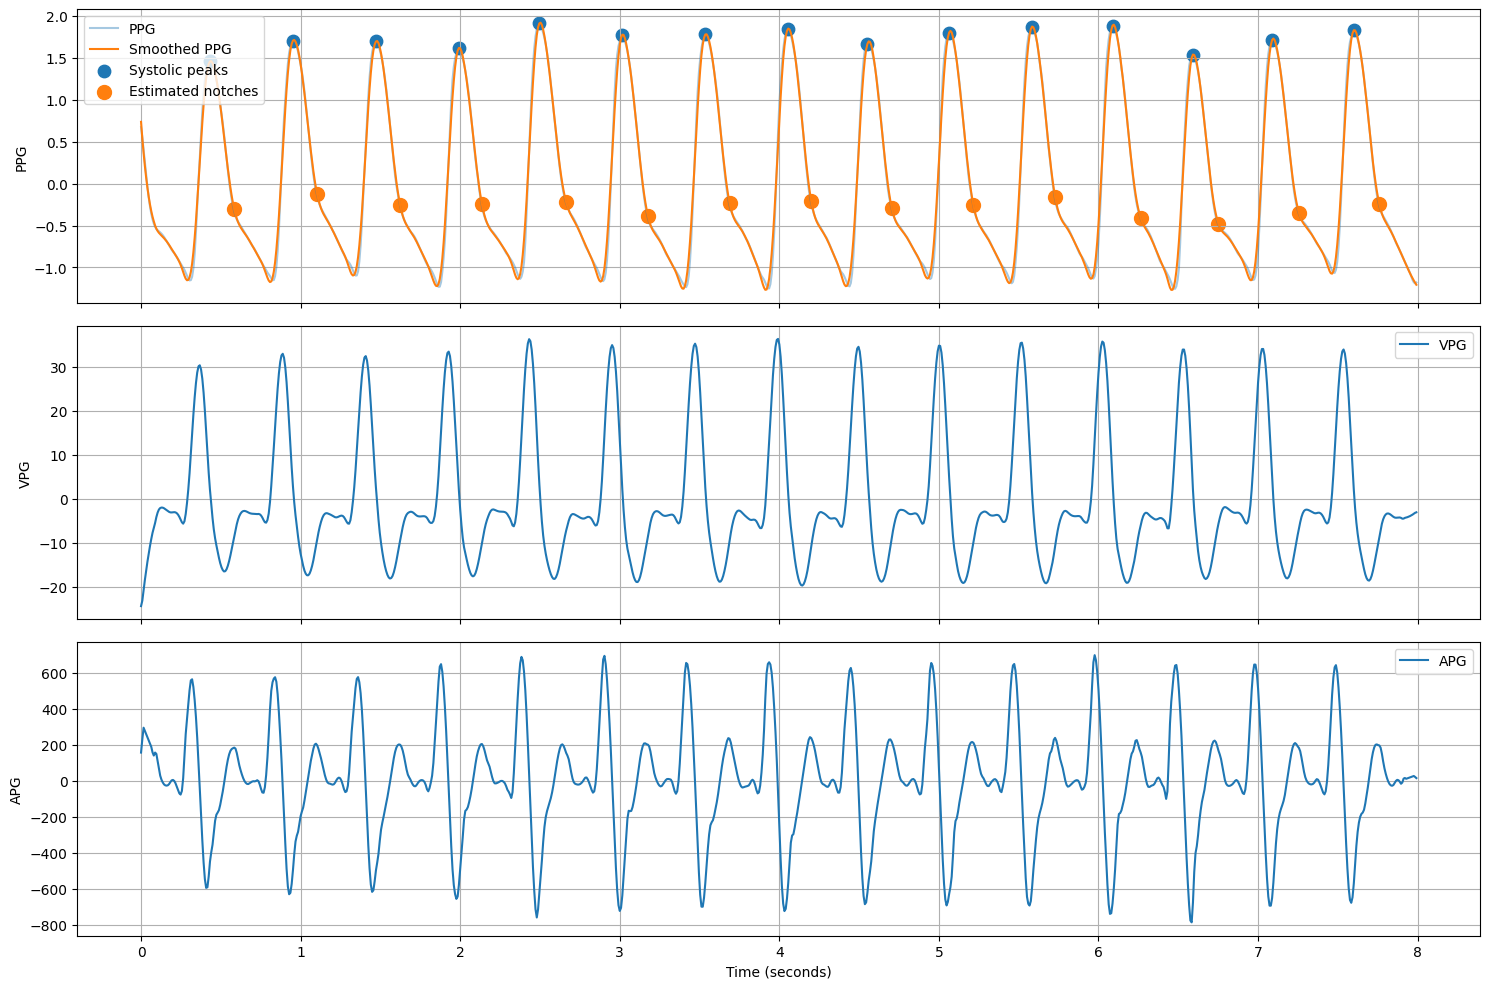

In [5]:
smooth_ppg = savgol_filter(
    ppg_window,
    window_length=21,
    polyorder=3
)
vpg = np.gradient(smooth_ppg) * FS
apg = np.gradient(vpg) * FS


time = np.arange(
    len(ppg_window)
) / FS

fig, axes = plt.subplots(
    3,
    1,
    figsize=(15, 10),
    sharex=True
)


# ==================================================
# PPG
# ==================================================

axes[0].plot(
    time,
    ppg_window,
    alpha=0.4,
    label="PPG"
)

axes[0].plot(
    time,
    smooth_ppg,
    label="Smoothed PPG"
)


# All systolic peaks

axes[0].scatter(
    sys_peaks / FS,
    smooth_ppg[sys_peaks],
    s=80,
    label="Systolic peaks"
)


# All detected notches

valid_notches = [
    n for n in notches
    if n is not None
]

if len(valid_notches) > 0:

    valid_notches = np.array(
        valid_notches,
        dtype=int
    )

    axes[0].scatter(
        valid_notches / FS,
        smooth_ppg[valid_notches],
        s=100,
        label="Estimated notches"
    )


axes[0].set_ylabel("PPG")
axes[0].legend()
axes[0].grid()


# ==================================================
# VPG
# ==================================================

axes[1].plot(
    time,
    vpg,
    label="VPG"
)

axes[1].set_ylabel("VPG")
axes[1].legend()
axes[1].grid()


# ==================================================
# APG
# ==================================================

axes[2].plot(
    time,
    apg,
    label="APG"
)

axes[2].set_xlabel("Time (seconds)")
axes[2].set_ylabel("APG")
axes[2].legend()
axes[2].grid()


plt.tight_layout()
plt.show()

In [6]:
delay_time =  get_delay_time(ppg_window)
print(delay_time)

[0.152 0.152 0.152 0.144 0.168 0.16  0.152 0.144 0.152 0.152 0.144 0.176
 0.16  0.168 0.16 ]


In [7]:
X_train, y_train, delay_train, X_val, y_val, delay_val, X_test, y_test, delay_test = prepare_UCI_dataset_w(
    data_path=DATA_PATH, window_size=1000, step_size=1000)

Total recordings: 12000
Train recordings: 8400
Validation recordings: 1200
Test recordings: 2400

Processing TRAIN recordings...


Processing recordings:   0%|          | 0/8400 [00:00<?, ?it/s]

Processing recordings: 100%|██████████| 8400/8400 [06:03<00:00, 23.11it/s]


Skipped recordings: 94

Processing VALIDATION recordings...


Processing recordings: 100%|██████████| 1200/1200 [00:52<00:00, 22.70it/s]


Skipped recordings: 14

Processing TEST recordings...


Processing recordings: 100%|██████████| 2400/2400 [01:48<00:00, 22.18it/s]


Skipped recordings: 16

DATASET SHAPES
X_train: torch.Size([228939, 1, 1000])
y_train: torch.Size([228939, 2])
delay_train: torch.Size([228939])
X_val: torch.Size([33012, 1, 1000])
y_val: torch.Size([33012, 2])
delay_val: torch.Size([33012])
X_test: torch.Size([67320, 1, 1000])
y_test: torch.Size([67320, 2])
delay_test: torch.Size([67320])


In [8]:
print("Shape:", delay_train.shape)
print("Dtype:", delay_train.dtype)
print("NaN count:", np.isnan(delay_train).sum())
delay_train_np = delay_train.detach().cpu().numpy().astype(np.float32)
print(
    "NaN percentage:",
    100 * np.isnan(delay_train_np).mean(),
    "%"
)

valid_delay = delay_train_np[
    np.isfinite(delay_train_np)
]

print("Valid values:", len(valid_delay))

if len(valid_delay) > 0:

    print("\nStatistics:")

    print(
        "Min    :",
        np.min(valid_delay)
    )

    print(
        "Max    :",
        np.max(valid_delay)
    )

    print(
        "Mean   :",
        np.mean(valid_delay)
    )

    print(
        "Median :",
        np.median(valid_delay)
    )

    print(
        "Std    :",
        np.std(valid_delay)
    )

if len(valid_delay) > 0:

    print("\nRange checks:")

    print(
        "Below 0.08 s:",
        np.sum(valid_delay < 0.08)
    )

    print(
        "Above 0.35 s:",
        np.sum(valid_delay > 0.35)
    )

    print(
        "Within 0.08–0.35 s:",
        np.sum(
            (valid_delay >= 0.08) &
            (valid_delay <= 0.35)
        )
    )


if len(valid_delay) > 0:

    print("\nPercentiles:")

    for p in [1, 5, 25, 50, 75, 95, 99]:

        print(
            f"{p:2d}% :",
            np.percentile(valid_delay, p)
        )

Shape: torch.Size([228939])
Dtype: torch.float32
NaN count: tensor(0)
NaN percentage: 0.0 %
Valid values: 228939

Statistics:
Min    : 0.088
Max    : 0.336
Mean   : 0.181016
Median : 0.176
Std    : 0.036720727

Range checks:
Below 0.08 s: 0
Above 0.35 s: 0
Within 0.08–0.35 s: 228939

Percentiles:
 1% : 0.112
 5% : 0.128
25% : 0.152
50% : 0.176
75% : 0.208
95% : 0.24399999
99% : 0.28


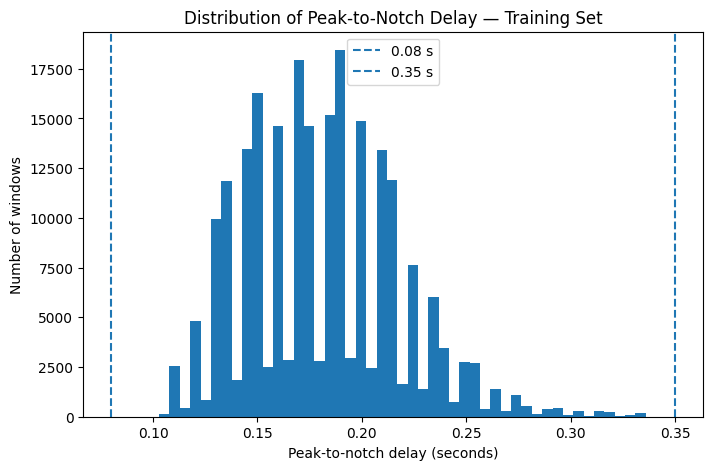

In [9]:
import matplotlib.pyplot as plt

valid_delay = delay_train[
    np.isfinite(delay_train)
]

plt.figure(figsize=(8, 5))

plt.hist(
    valid_delay,
    bins=50
)

plt.xlabel("Peak-to-notch delay (seconds)")
plt.ylabel("Number of windows")
plt.title("Distribution of Peak-to-Notch Delay — Training Set")

plt.axvline(
    0.08,
    linestyle="--",
    label="0.08 s"
)

plt.axvline(
    0.35,
    linestyle="--",
    label="0.35 s"
)

plt.legend()

plt.show()

In [10]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("delay_train:", delay_train.shape)

print(
    "Number of windows:",
    len(X_train)
)

print(
    "Number of BP labels:",
    len(y_train)
)

print(
    "Number of delays:",
    len(delay_train)
)

X_train: torch.Size([228939, 1, 1000])
y_train: torch.Size([228939, 2])
delay_train: torch.Size([228939])
Number of windows: 228939
Number of BP labels: 228939
Number of delays: 228939


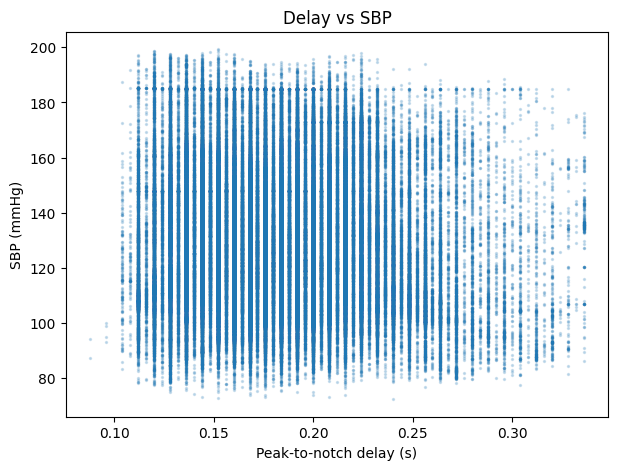

In [11]:
plt.figure(figsize=(7, 5))

plt.scatter(
    valid_delay,
    y_train[np.isfinite(delay_train), 0],
    s=2,
    alpha=0.2
)

plt.xlabel("Peak-to-notch delay (s)")
plt.ylabel("SBP (mmHg)")
plt.title("Delay vs SBP")

plt.show()

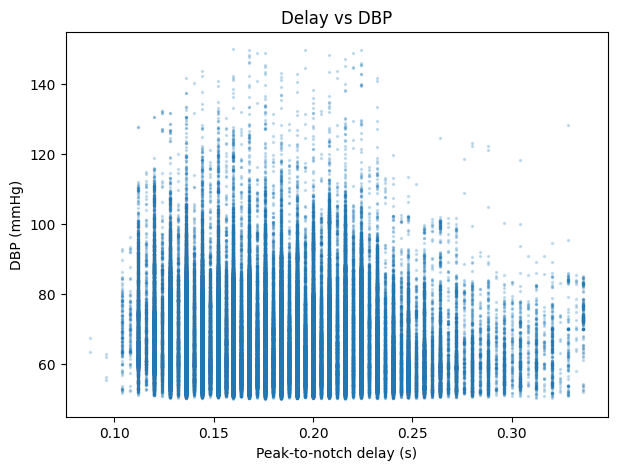

In [12]:
plt.figure(figsize=(7, 5))

plt.scatter(
    valid_delay,
    y_train[np.isfinite(delay_train), 1],
    s=2,
    alpha=0.2
)

plt.xlabel("Peak-to-notch delay (s)")
plt.ylabel("DBP (mmHg)")
plt.title("Delay vs DBP")

plt.show()

## RC Estimation ##

In [13]:
RC, RC_values = estimate_RC(
    sbp=y_train[:, 0].numpy(),
    dbp=y_train[:, 1].numpy(),
    delay=delay_train
)

Total windows: 228939
Valid windows: 228939
Valid percentage: 100.0 %

Windkessel RC Estimation
Median RC : 0.2678 s
Mean RC   : 0.2898 s
Std RC    : 0.1106 s
Min RC    : 0.1139 s
Max RC    : 1.4589 s


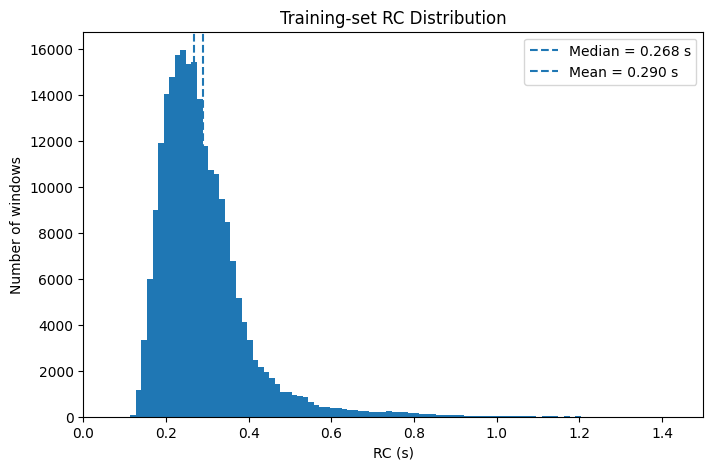

In [14]:
plt.figure(figsize=(8, 5))

plt.hist(
    RC_values,
    bins=100
)

plt.axvline(
    np.median(RC_values),
    linestyle="--",
    label=f"Median = {np.median(RC_values):.3f} s"
)
plt.axvline(
    np.mean(RC_values),
    linestyle="--",
    label=f"Mean = {np.mean(RC_values):.3f} s"
)

plt.xlabel("RC (s)")
plt.xlim(0,1.5)
plt.ylabel("Number of windows")
plt.title("Training-set RC Distribution")
plt.legend()

plt.show()

It's a highly skewed distribution, so using mean won't be a good idea

In [15]:
for p in [1, 5, 25, 50, 75, 90, 95, 99, 99.5, 99.9]:
    print(
        f"{p:5.1f}% : "
        f"{np.percentile(RC_values, p):.4f} s"
    )

  1.0% : 0.1460 s
  5.0% : 0.1692 s
 25.0% : 0.2187 s
 50.0% : 0.2678 s
 75.0% : 0.3316 s
 90.0% : 0.4048 s
 95.0% : 0.4842 s
 99.0% : 0.7398 s
 99.5% : 0.8245 s
 99.9% : 1.0383 s


In [16]:
RC = 0.2994

sbp = y_train[:, 0].cpu().numpy()
dbp = y_train[:, 1].cpu().numpy()
delay = delay_train.cpu().numpy()

dbp_physics = (
    sbp *
    np.exp(-delay / RC)
)

physics_mae = np.mean(
    np.abs(dbp_physics - dbp)
)

physics_rmse = np.sqrt(
    np.mean(
        (dbp_physics - dbp) ** 2
    )
)

print("Physics-only DBP MAE :", physics_mae)
print("Physics-only DBP RMSE:", physics_rmse)

Physics-only DBP MAE : 11.560565
Physics-only DBP RMSE: 14.763834


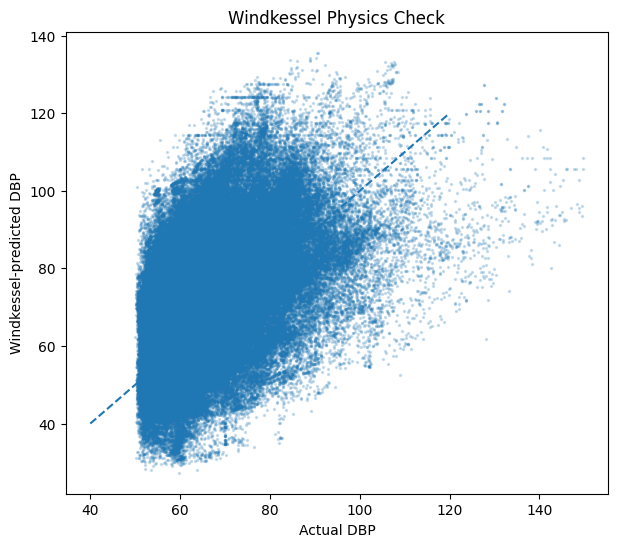

In [17]:
plt.figure(figsize=(7, 6))

plt.scatter(
    dbp,
    dbp_physics,
    s=2,
    alpha=0.2
)

plt.plot(
    [40, 120],
    [40, 120],
    linestyle="--"
)

plt.xlabel("Actual DBP")
plt.ylabel("Windkessel-predicted DBP")
plt.title("Windkessel Physics Check")

plt.show()

In [18]:
rc_values, mae_values, rmse_values, best_RC_MAE, best_RC_RMSE = grid_search_RC(
    sbp=y_train[:, 0].cpu().numpy(),
    dbp=y_train[:, 1].cpu().numpy(),
    delay=delay_train.cpu().numpy(),
    rc_min=0.10,
    rc_max=1.00,
    rc_step=0.005
)
RC = best_RC_MAE

Valid samples: 228939

RC GRID SEARCH RESULTS
Best RC by MAE  : 0.2650 s
Best MAE        : 10.7580 mmHg

Best RC by RMSE : 0.2650 s
Best RMSE       : 13.6591 mmHg


## Establishing Baseline using 1D ResNet ##

In [19]:
import random
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


# ============================================================
# Device
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

Device: cuda


In [20]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: torch.Size([228939, 1, 1000])
y_train: torch.Size([228939, 2])
X_val: torch.Size([33012, 1, 1000])
y_val: torch.Size([33012, 2])
X_test: torch.Size([67320, 1, 1000])
y_test: torch.Size([67320, 2])


In [21]:
train_loader, val_loader, test_loader = create_data_loaders(
    X_train, y_train,
    X_val, y_val,  
    X_test, y_test)


Epoch [01/50] LR: 1.00e-04 | Train MSE: 7720.8420 | Train SBP MSE: 12732.7551 | Train DBP MSE: 2708.9288 | Train SBP RMSE: 112.8395 | Train DBP RMSE: 52.0474 | Val MSE: 4436.2712 | Val SBP MSE: 7959.1972 | Val DBP MSE: 913.3452 | Val SBP RMSE: 89.2143 | Val DBP RMSE: 30.2216
Epoch [02/50] LR: 1.00e-04 | Train MSE: 2917.3746 | Train SBP MSE: 5382.3849 | Train DBP MSE: 452.3644 | Train SBP RMSE: 73.3647 | Train DBP RMSE: 21.2689 | Val MSE: 1417.2061 | Val SBP MSE: 2708.9987 | Val DBP MSE: 125.4135 | Val SBP RMSE: 52.0480 | Val DBP RMSE: 11.1988
Epoch [03/50] LR: 1.00e-04 | Train MSE: 717.8554 | Train SBP MSE: 1328.1199 | Train DBP MSE: 107.5910 | Train SBP RMSE: 36.4434 | Train DBP RMSE: 10.3726 | Val MSE: 264.0389 | Val SBP MSE: 360.4285 | Val DBP MSE: 167.6493 | Val SBP RMSE: 18.9850 | Val DBP RMSE: 12.9479
Epoch [04/50] LR: 1.00e-04 | Train MSE: 245.8229 | Train SBP MSE: 389.2726 | Train DBP MSE: 102.3732 | Train SBP RMSE: 19.7300 | Train DBP RMSE: 10.1180 | Val MSE: 206.3423 | Val SB

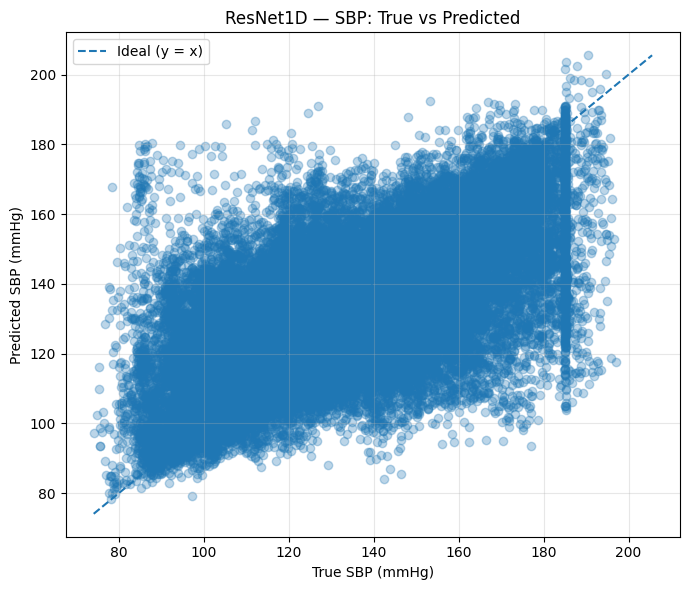

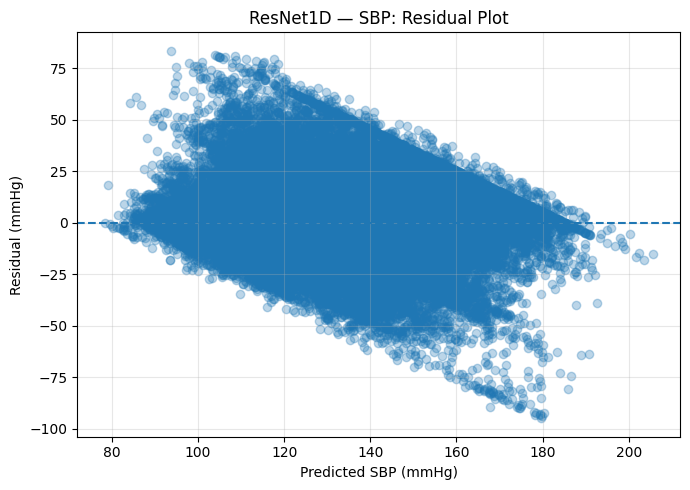

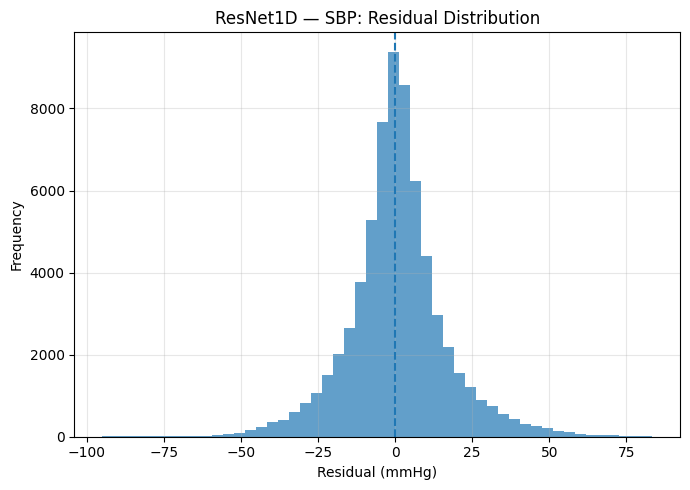

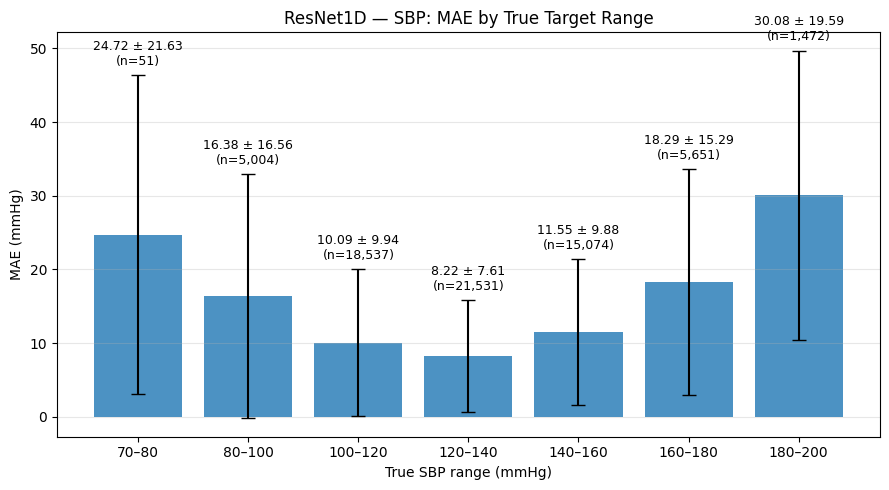



DBP TEST RESULTS
RMSE: 8.6288
MSE : 74.4567
R²  : 0.3996
MAE : 5.8513


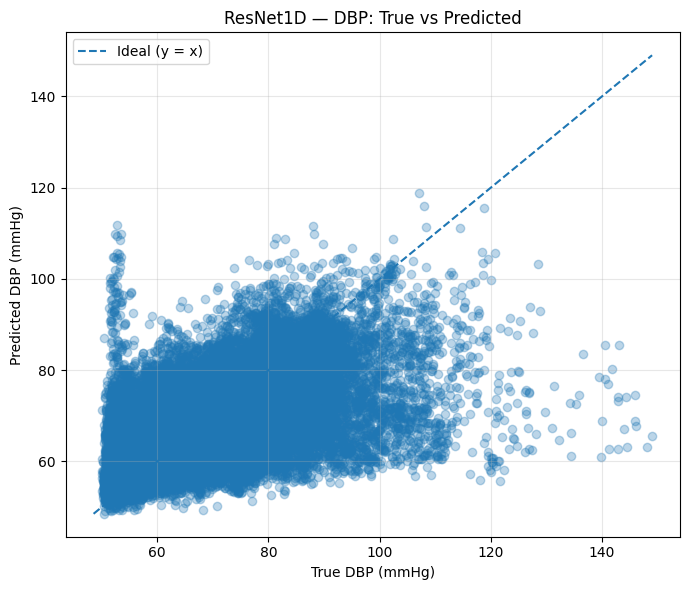

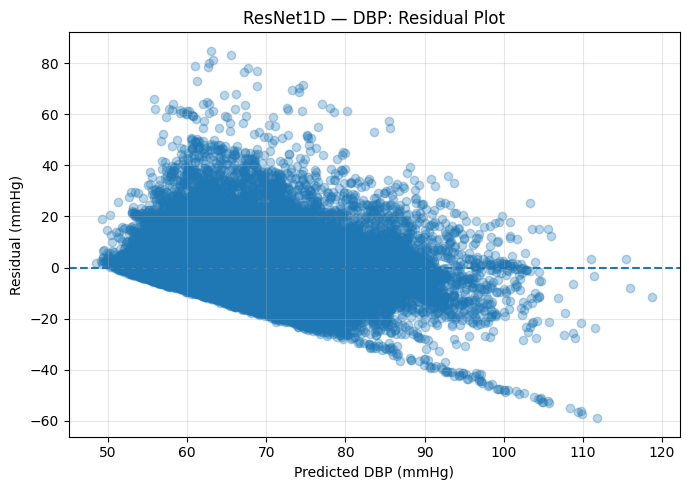

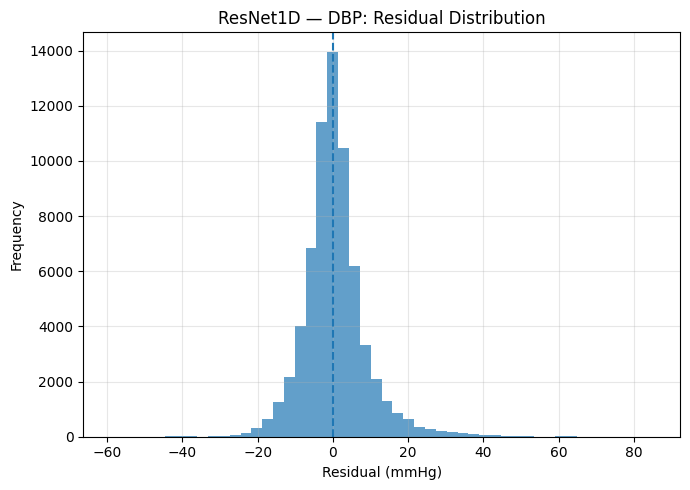

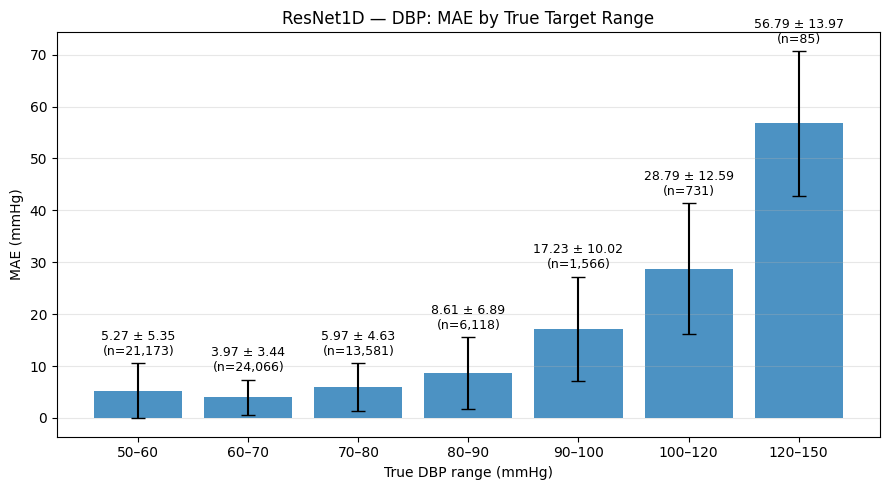

In [22]:
model, history, y_true, y_pred = train_resnet1d(
    train_loader,
    val_loader,
    test_loader,
    device,
    epochs=50
)

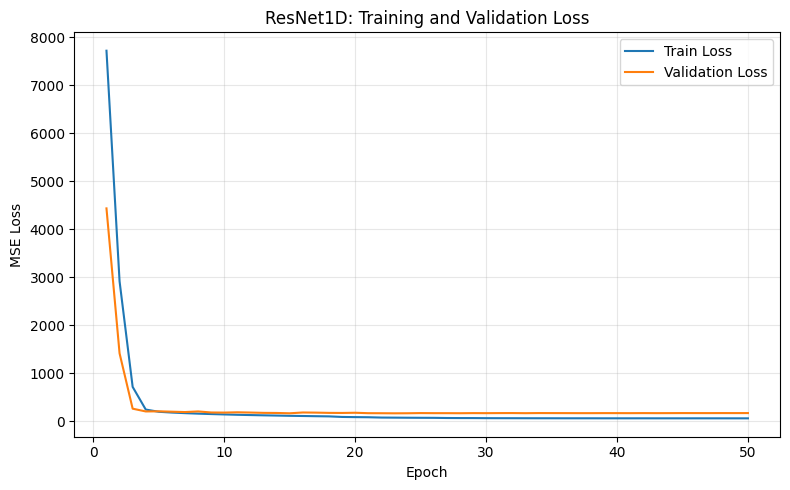

In [23]:
plot_training_loss(
    history,
    model_name="ResNet1D"
)

## Physics Informed Windkessel ##

Epoch [001/50] | LR: 1.00e-04 | Train Total: 15439.9403 | Train SBP MSE: 12785.5987 | Train DBP MSE: 2654.3328 | Train Phys: 88.1106 | Train RMSE: SBP=113.073, DBP=51.520 | Val Total: 9159.6202 | Val SBP MSE: 8284.8121 | Val DBP MSE: 874.7775 | Val Phys: 306.0363 | Val RMSE: SBP=91.021, DBP=29.577 | ✓
Epoch [002/50] | LR: 1.00e-04 | Train Total: 5049.2672 | Train SBP MSE: 4727.1955 | Train DBP MSE: 322.0255 | Train Phys: 461.6708 | Train RMSE: SBP=68.755, DBP=17.945 | Val Total: 1553.0255 | Val SBP MSE: 1422.1096 | Val DBP MSE: 130.8704 | Val Phys: 455.0777 | Val RMSE: SBP=37.711, DBP=11.440 | ✓
Epoch [003/50] | LR: 1.00e-04 | Train Total: 940.3904 | Train SBP MSE: 836.2789 | Train DBP MSE: 104.0912 | Train Phys: 203.1539 | Train RMSE: SBP=28.918, DBP=10.203 | Val Total: 461.6719 | Val SBP MSE: 365.5568 | Val DBP MSE: 96.1066 | Val Phys: 84.3753 | Val RMSE: SBP=19.120, DBP=9.803 | ✓
Epoch [004/50] | LR: 1.00e-04 | Train Total: 425.2556 | Train SBP MSE: 326.0457 | Train DBP MSE: 99.2010

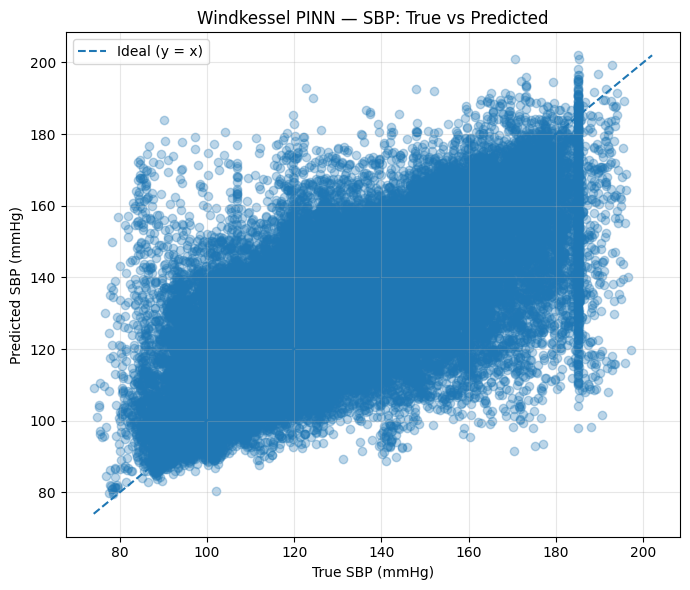

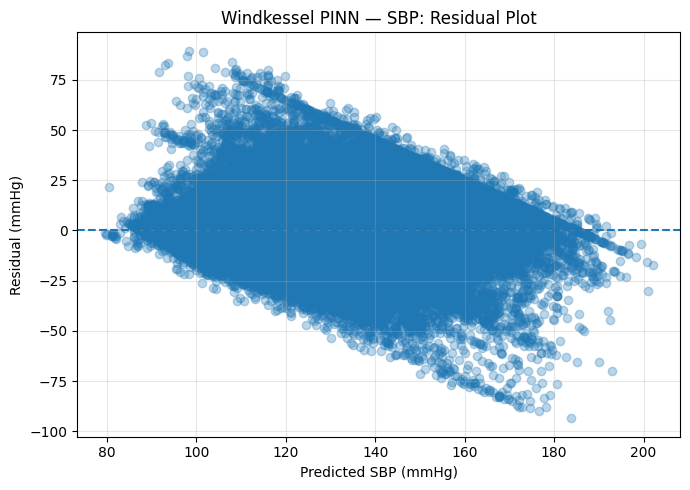

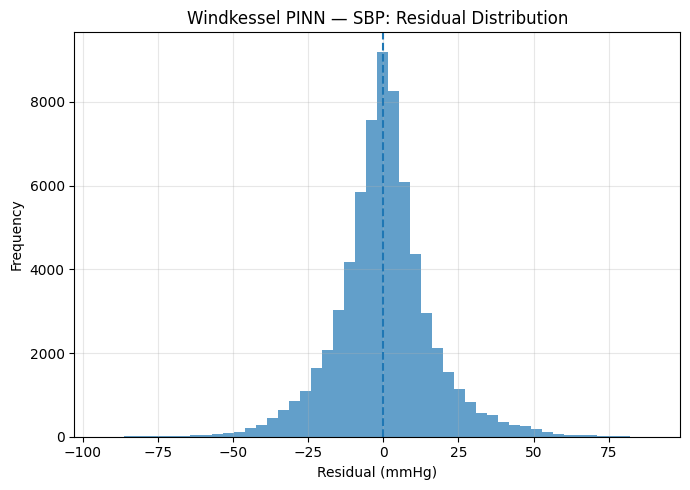

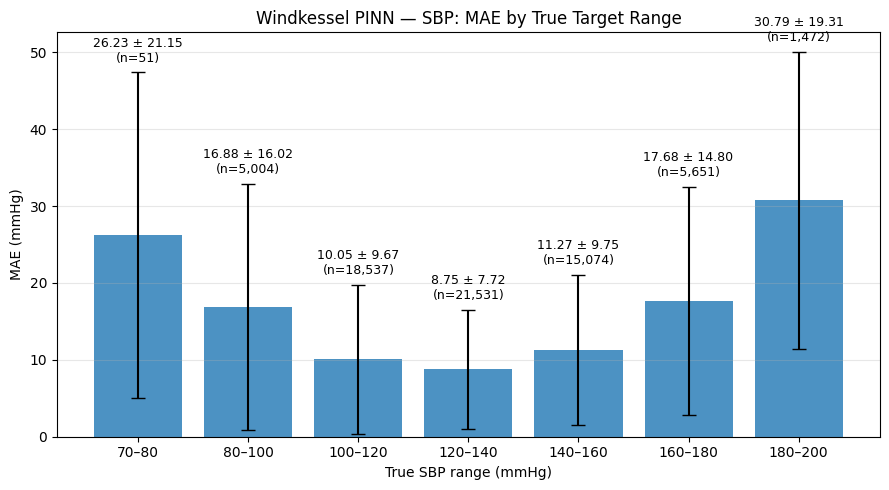


WINDKESSEL PINN — DBP TEST RESULTS
RMSE: 8.6364
MSE : 74.5868
R²  : 0.3986
MAE : 5.9247


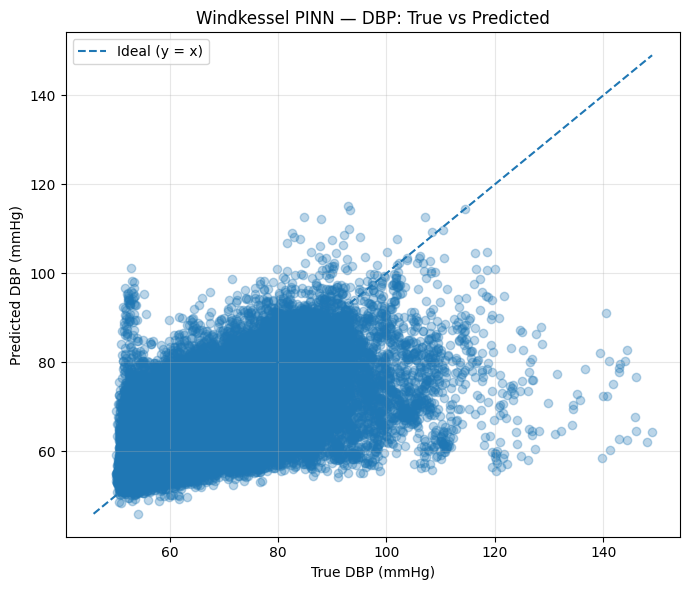

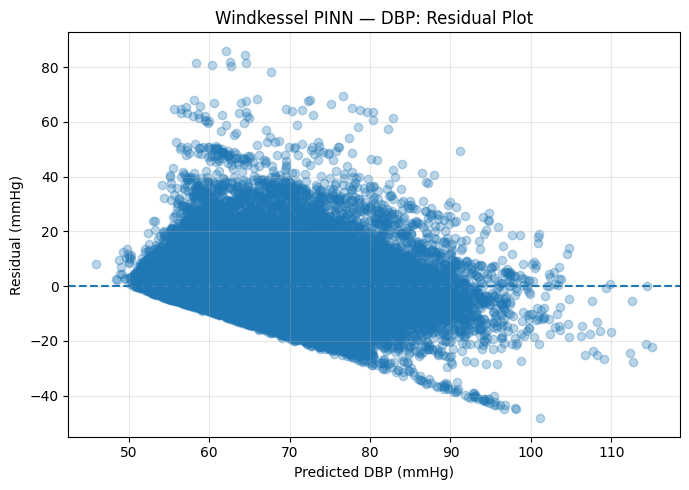

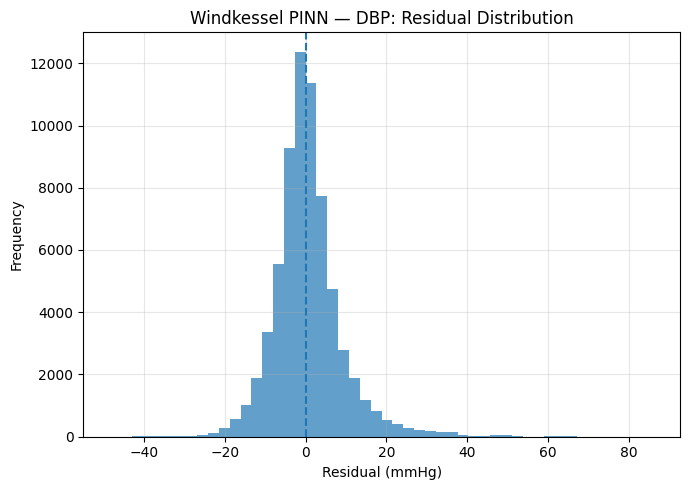

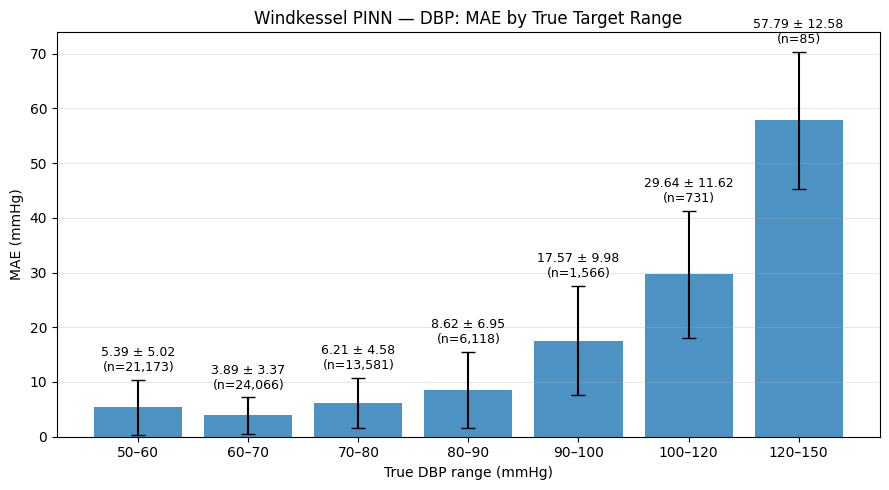

In [24]:
model, results = run_windkessel_pinn(
    X_train, y_train, delay_train,
    X_val, y_val, delay_val,
    X_test, y_test, delay_test,
    RC=RC,
    device=device,
    lambda_phys=0.0001
)

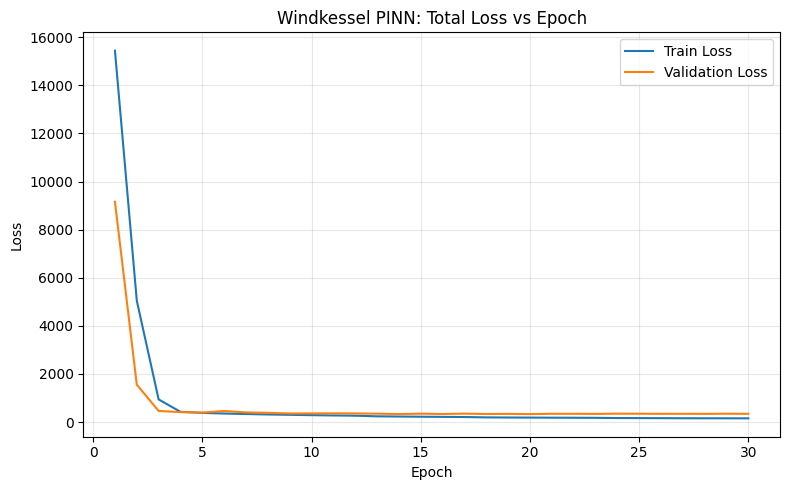

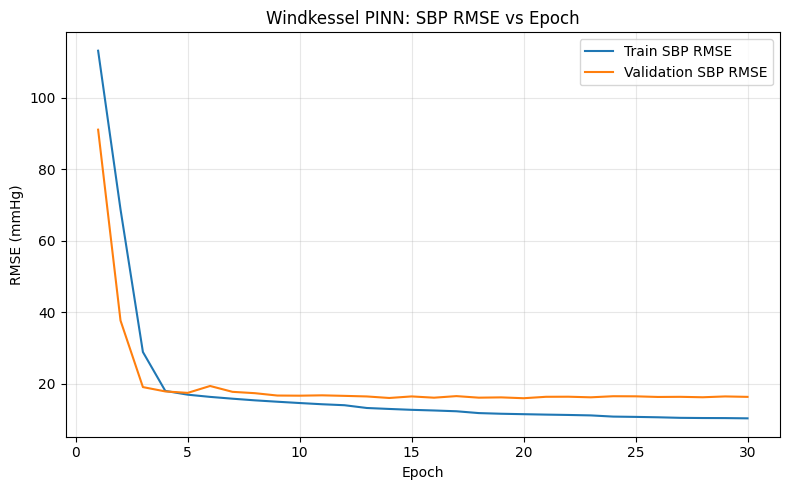

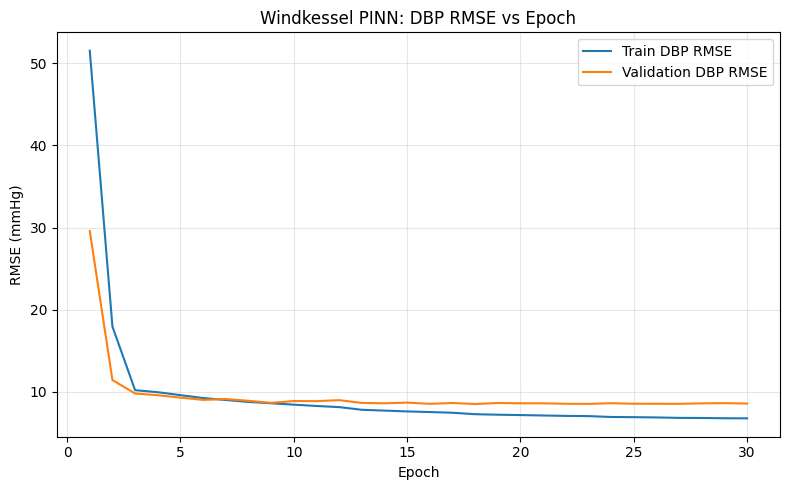

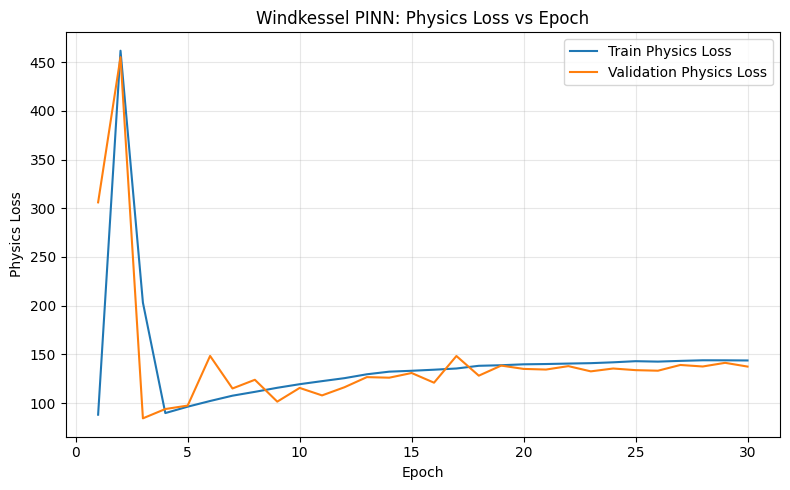

In [25]:
plot_pinn_training_metrics(
    results["history"],
    model_name="Windkessel PINN"
)

Epoch [001/50] | LR: 1.00e-04 | Train Total: 16174.5546 | Train SBP MSE: 13192.1672 | Train DBP MSE: 2982.3402 | Train Phys: 47.2725 | Train RMSE: SBP=114.857, DBP=54.611 | Val Total: 11222.5027 | Val SBP MSE: 9701.1671 | Val DBP MSE: 1521.1918 | Val Phys: 143.7354 | Val RMSE: SBP=98.494, DBP=39.002 | ✓
Epoch [002/50] | LR: 1.00e-04 | Train Total: 6176.5090 | Train SBP MSE: 5641.3646 | Train DBP MSE: 534.7673 | Train Phys: 377.0889 | Train RMSE: SBP=75.109, DBP=23.125 | Val Total: 3004.9206 | Val SBP MSE: 2869.4373 | Val DBP MSE: 135.0778 | Val Phys: 405.5709 | Val RMSE: SBP=53.567, DBP=11.622 | ✓
Epoch [003/50] | LR: 1.00e-04 | Train Total: 1143.9501 | Train SBP MSE: 1034.1751 | Train DBP MSE: 109.5272 | Train Phys: 247.7602 | Train RMSE: SBP=32.159, DBP=10.466 | Val Total: 507.6841 | Val SBP MSE: 408.2147 | Val DBP MSE: 99.3699 | Val Phys: 99.5587 | Val RMSE: SBP=20.204, DBP=9.968 | ✓
Epoch [004/50] | LR: 1.00e-04 | Train Total: 452.0251 | Train SBP MSE: 347.8521 | Train DBP MSE: 104

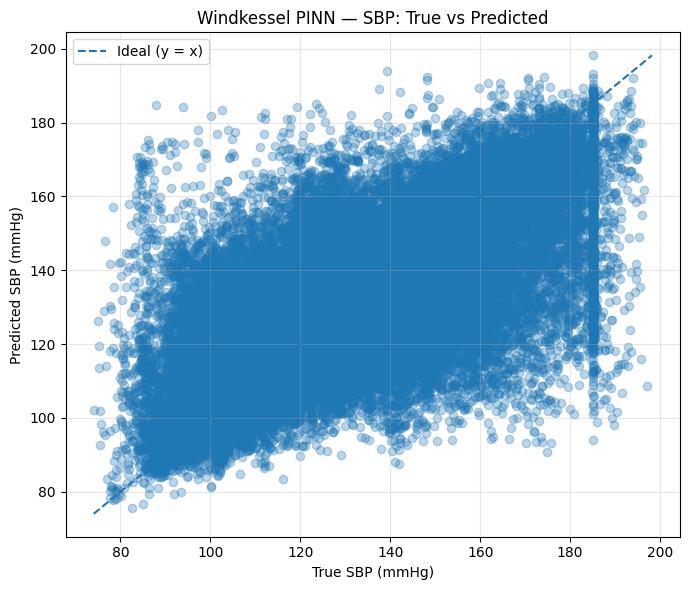

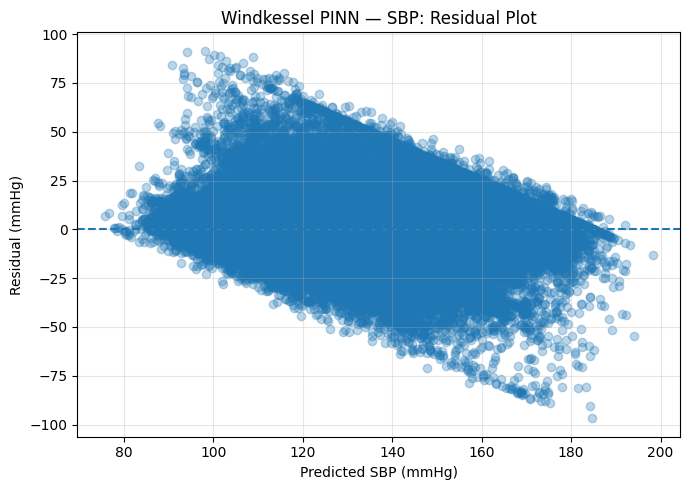

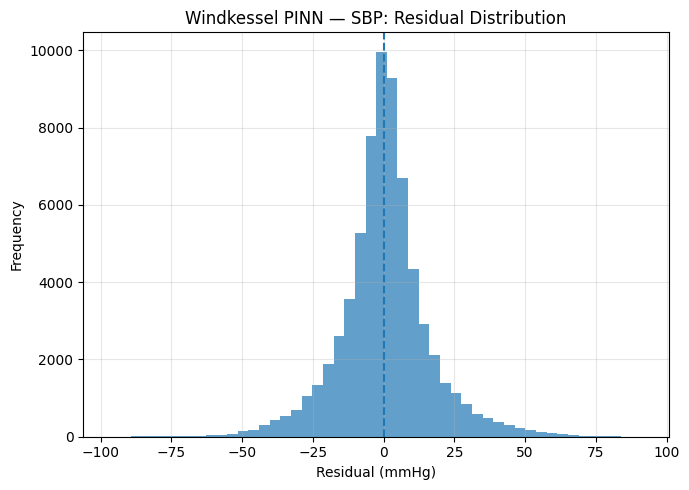

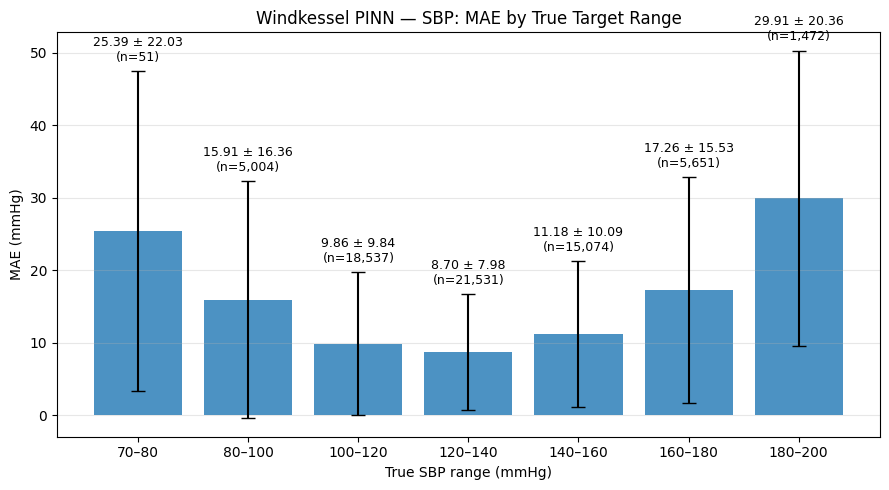


WINDKESSEL PINN — DBP TEST RESULTS
RMSE: 8.5956
MSE : 73.8844
R²  : 0.4042
MAE : 5.8059


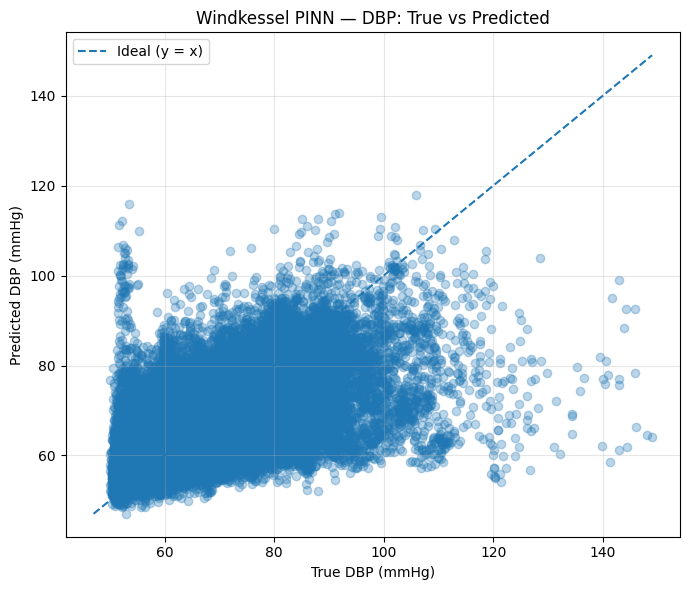

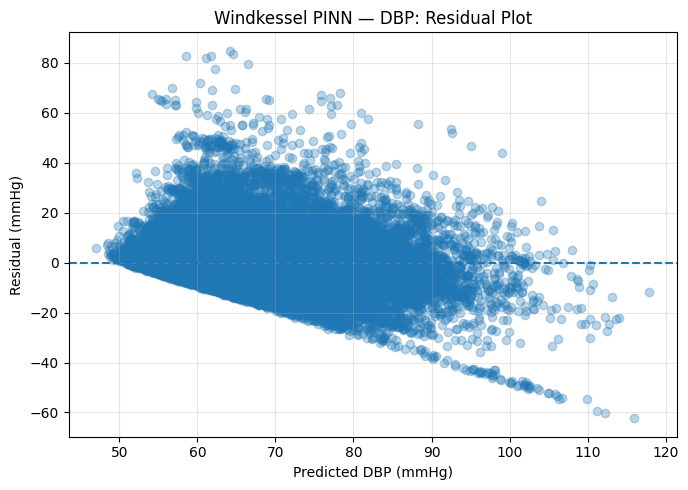

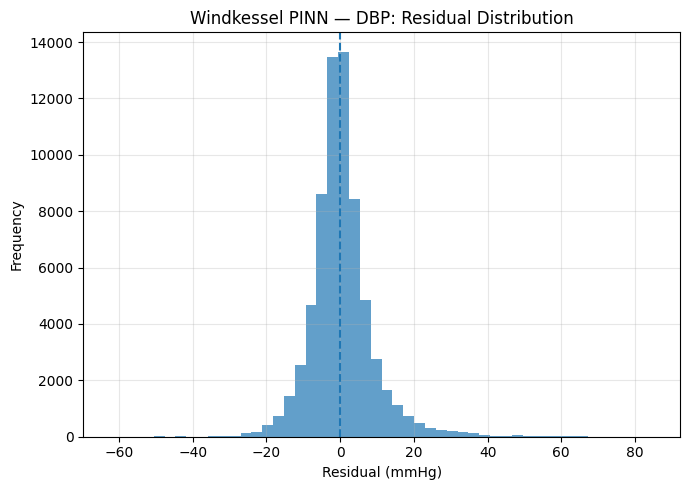

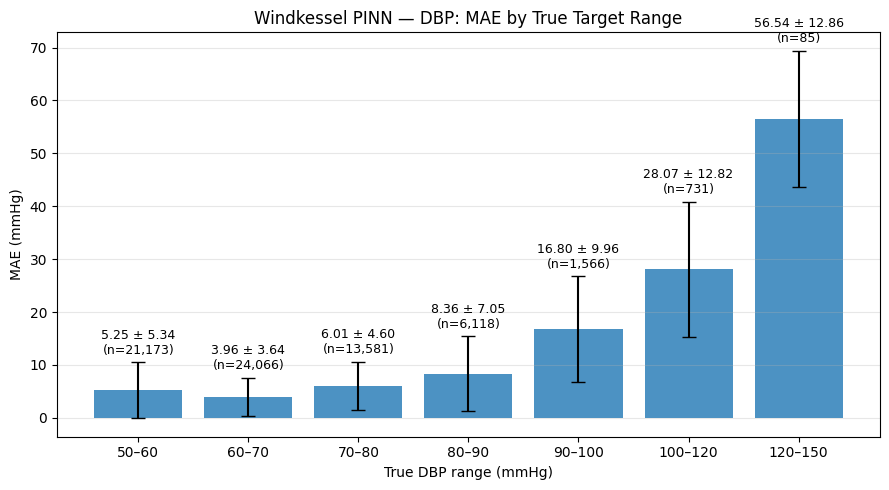

In [26]:
model, results = run_windkessel_pinn(
    X_train, y_train, delay_train,
    X_val, y_val, delay_val,
    X_test, y_test, delay_test,
    RC=RC,
    device=device,
    lambda_phys=0.001
)

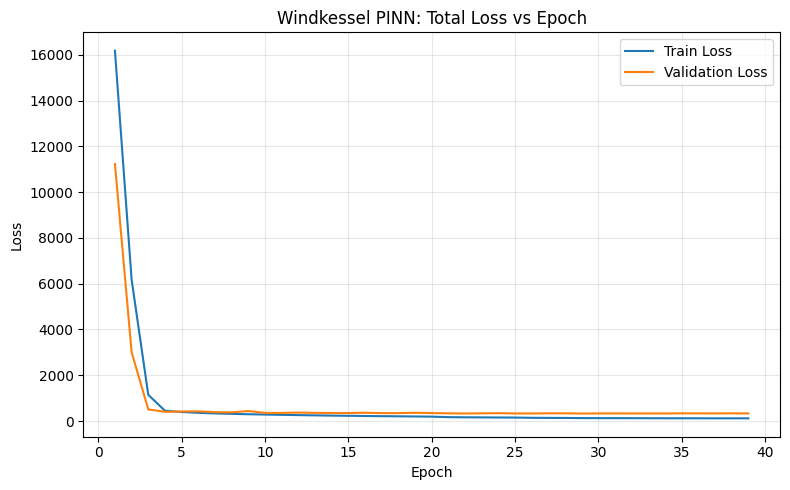

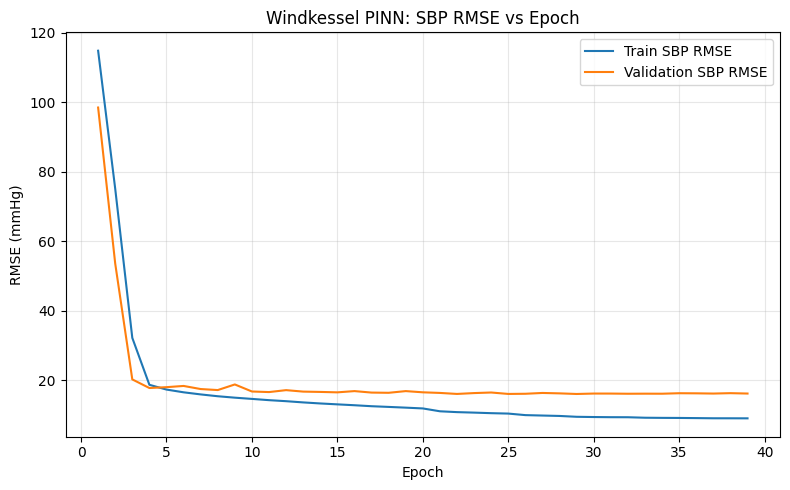

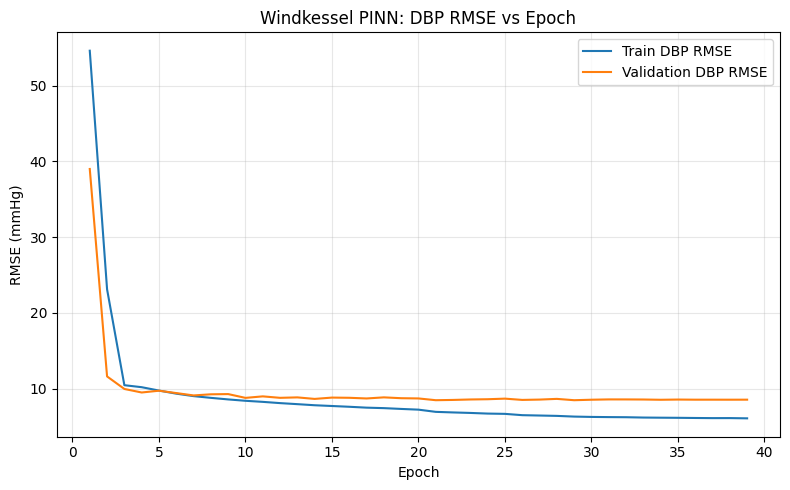

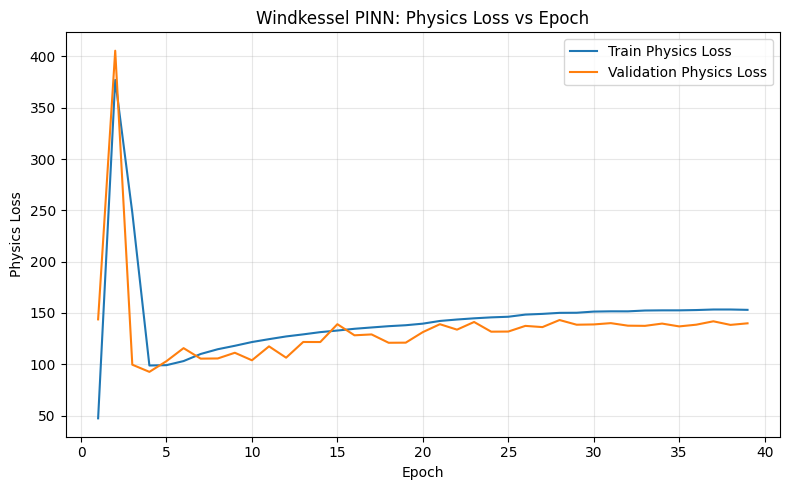

In [27]:
plot_pinn_training_metrics(
    results["history"],
    model_name="Windkessel PINN"
)

Epoch [001/50] | LR: 1.00e-04 | Train Total: 15534.2257 | Train SBP MSE: 12675.8845 | Train DBP MSE: 2857.9122 | Train Phys: 42.8934 | Train RMSE: SBP=112.587, DBP=53.459 | Val Total: 9665.1553 | Val SBP MSE: 8476.5671 | Val DBP MSE: 1186.8698 | Val Phys: 171.8365 | Val RMSE: SBP=92.068, DBP=34.451 | ✓
Epoch [002/50] | LR: 1.00e-04 | Train Total: 5849.6463 | Train SBP MSE: 5334.5660 | Train DBP MSE: 511.7050 | Train Phys: 337.5260 | Train RMSE: SBP=73.038, DBP=22.621 | Val Total: 2780.1607 | Val SBP MSE: 2644.8132 | Val DBP MSE: 131.7010 | Val Phys: 364.6540 | Val RMSE: SBP=51.428, DBP=11.476 | ✓
Epoch [003/50] | LR: 1.00e-04 | Train Total: 1128.8635 | Train SBP MSE: 1020.3365 | Train DBP MSE: 106.2468 | Train Phys: 228.0186 | Train RMSE: SBP=31.943, DBP=10.308 | Val Total: 447.3796 | Val SBP MSE: 328.9773 | Val DBP MSE: 117.4640 | Val Phys: 93.8318 | Val RMSE: SBP=18.138, DBP=10.838 | ✓
Epoch [004/50] | LR: 1.00e-04 | Train Total: 433.7469 | Train SBP MSE: 331.9113 | Train DBP MSE: 10

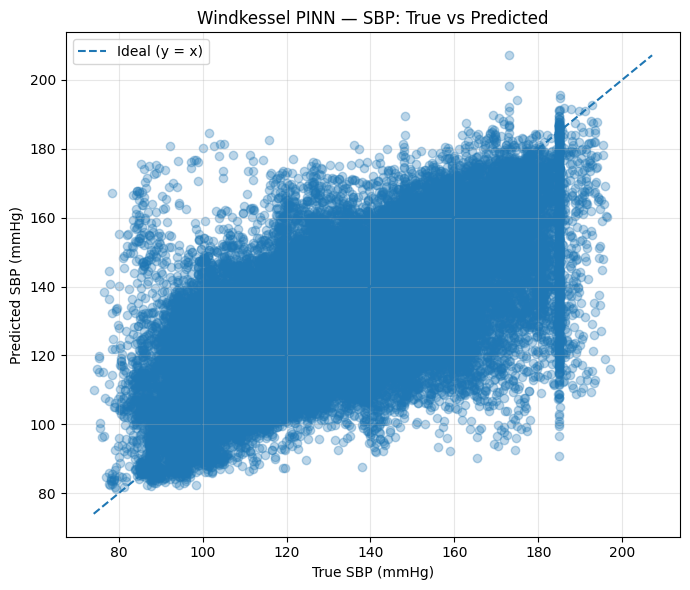

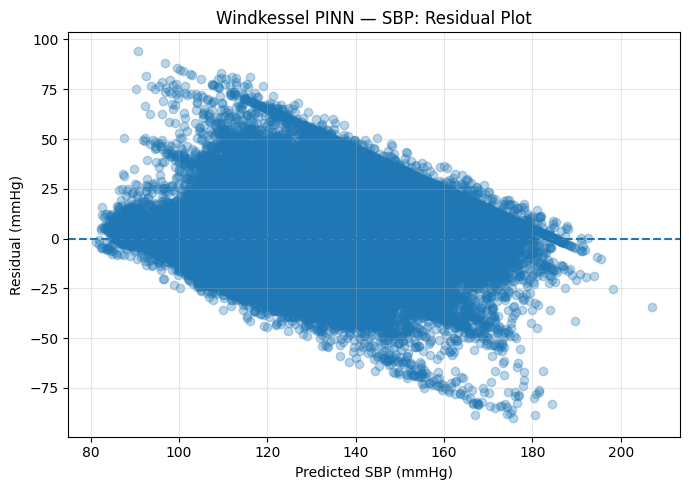

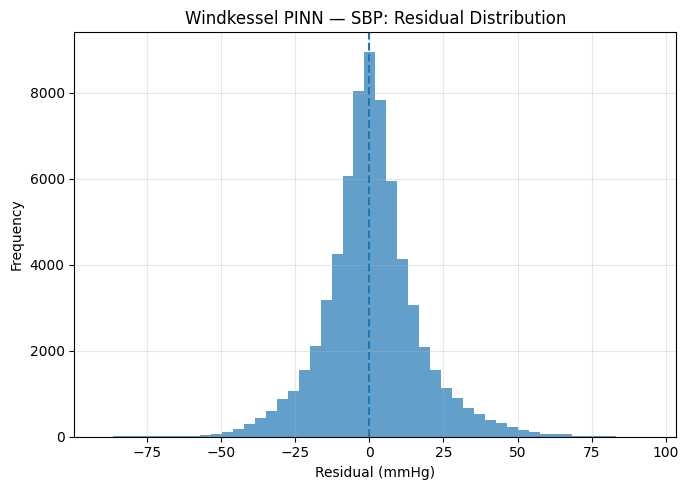

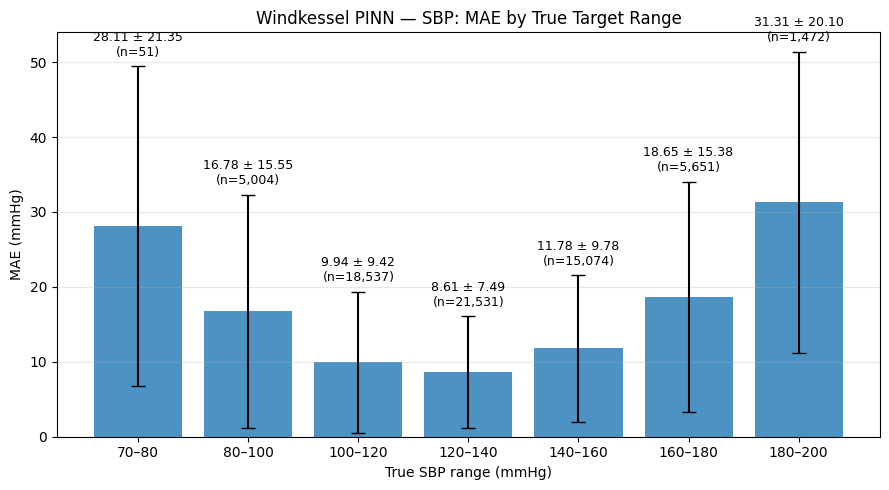


WINDKESSEL PINN — DBP TEST RESULTS
RMSE: 8.7391
MSE : 76.3722
R²  : 0.3842
MAE : 5.9795


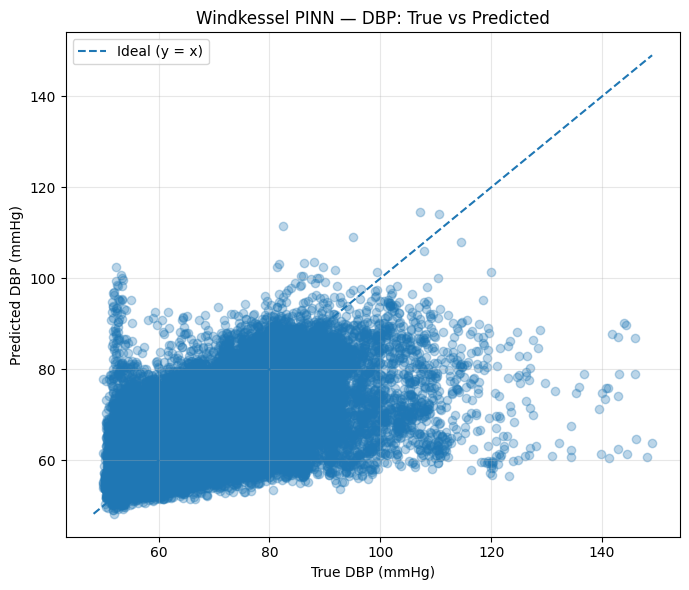

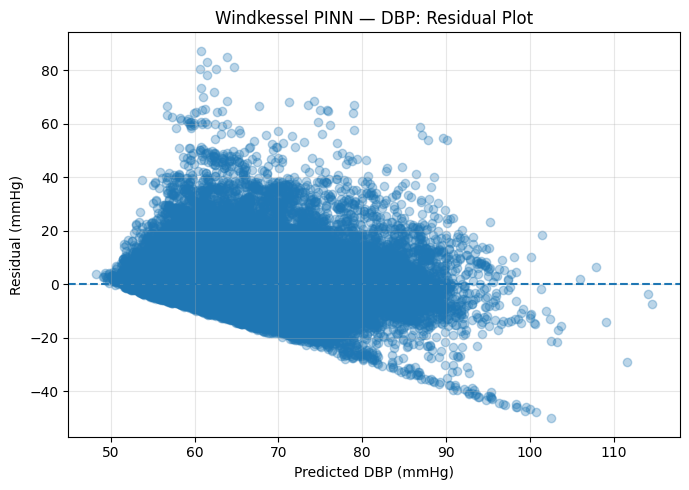

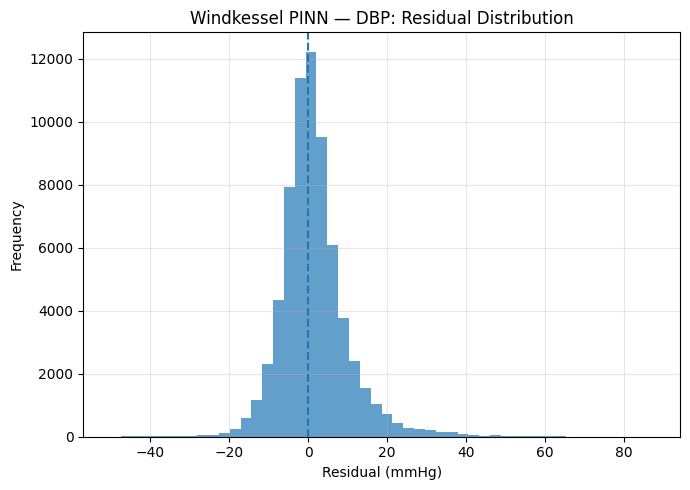

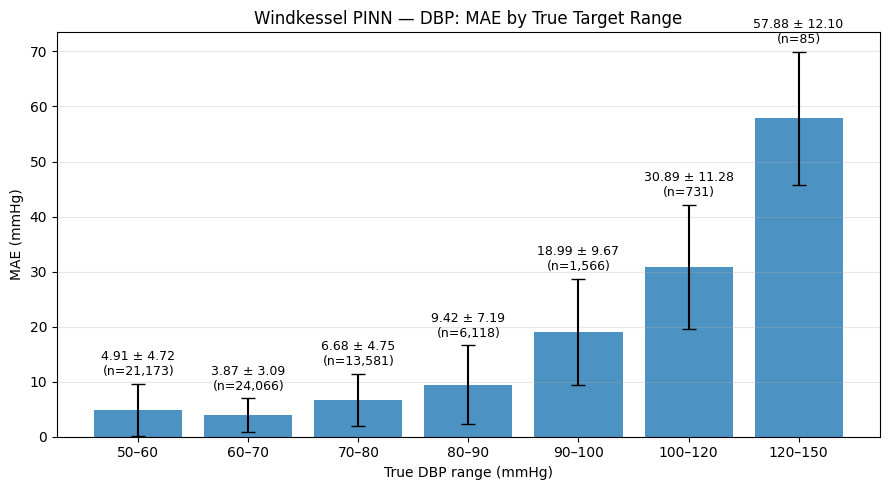

In [28]:
model, results = run_windkessel_pinn(
    X_train, y_train, delay_train,
    X_val, y_val, delay_val,
    X_test, y_test, delay_test,
    RC=RC,
    device=device,
    lambda_phys=0.01
)

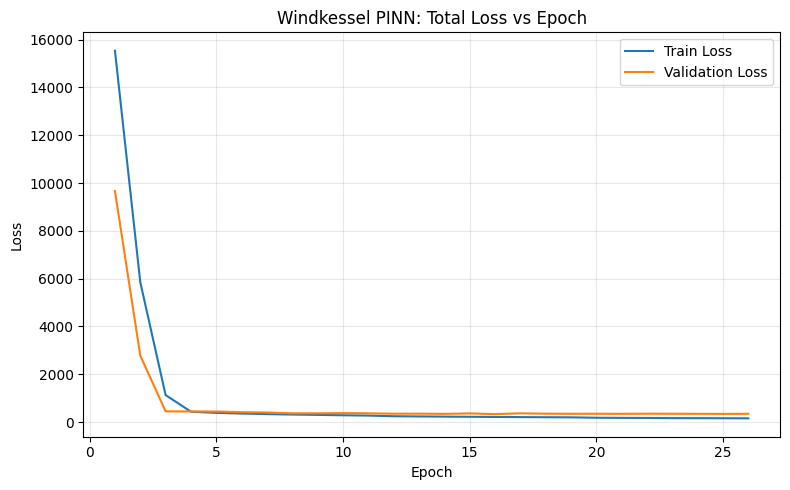

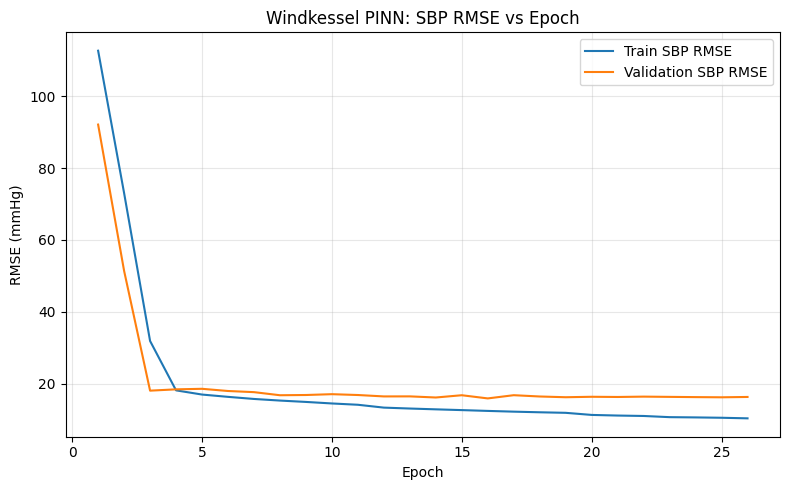

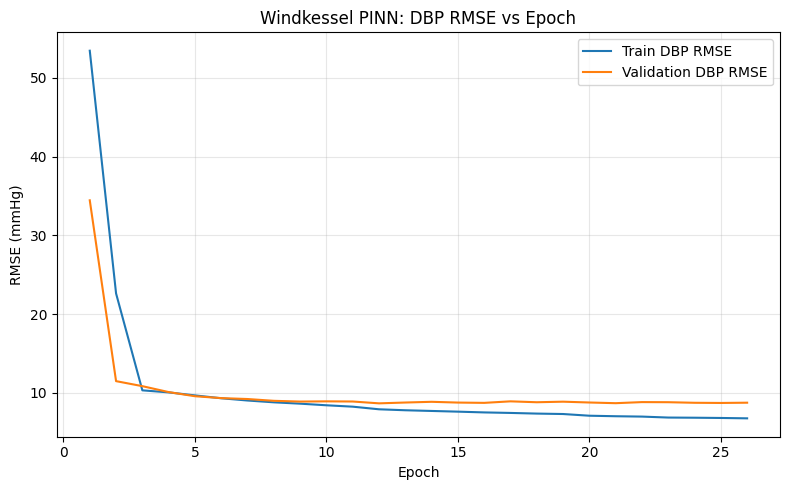

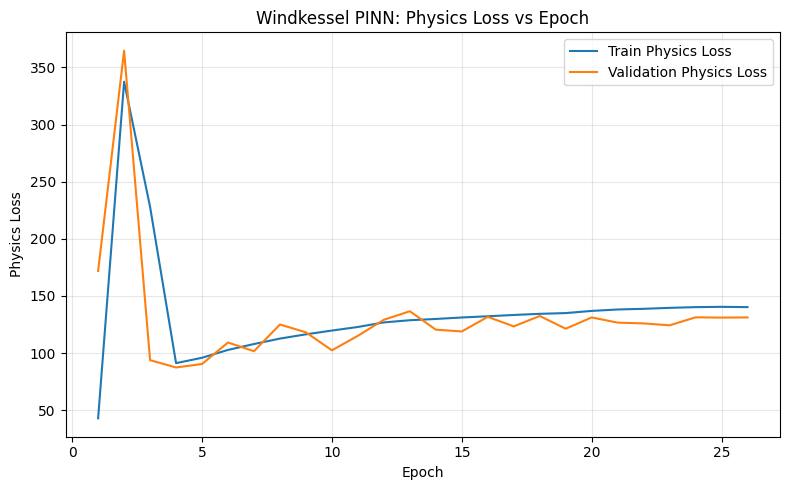

In [29]:
plot_pinn_training_metrics(
    results["history"],
    model_name="Windkessel PINN"
)

Epoch [001/50] | LR: 1.00e-04 | Train Total: 15594.7290 | Train SBP MSE: 12770.2329 | Train DBP MSE: 2819.5670 | Train Phys: 49.2909 | Train RMSE: SBP=113.005, DBP=53.100 | Val Total: 10918.4907 | Val SBP MSE: 9471.8366 | Val DBP MSE: 1431.7805 | Val Phys: 148.7358 | Val RMSE: SBP=97.323, DBP=37.839 | ✓
Epoch [002/50] | LR: 1.00e-04 | Train Total: 5996.3580 | Train SBP MSE: 5451.6318 | Train DBP MSE: 510.1837 | Train Phys: 345.4253 | Train RMSE: SBP=73.835, DBP=22.587 | Val Total: 1959.0934 | Val SBP MSE: 1814.5216 | Val DBP MSE: 102.2916 | Val Phys: 422.8018 | Val RMSE: SBP=42.597, DBP=10.114 | ✓
Epoch [003/50] | LR: 1.00e-04 | Train Total: 1160.9759 | Train SBP MSE: 1034.0443 | Train DBP MSE: 106.2944 | Train Phys: 206.3721 | Train RMSE: SBP=32.157, DBP=10.310 | Val Total: 668.6834 | Val SBP MSE: 558.6458 | Val DBP MSE: 102.1554 | Val Phys: 78.8220 | Val RMSE: SBP=23.636, DBP=10.107 | ✓
Epoch [004/50] | LR: 1.00e-04 | Train Total: 443.2029 | Train SBP MSE: 333.6512 | Train DBP MSE: 1

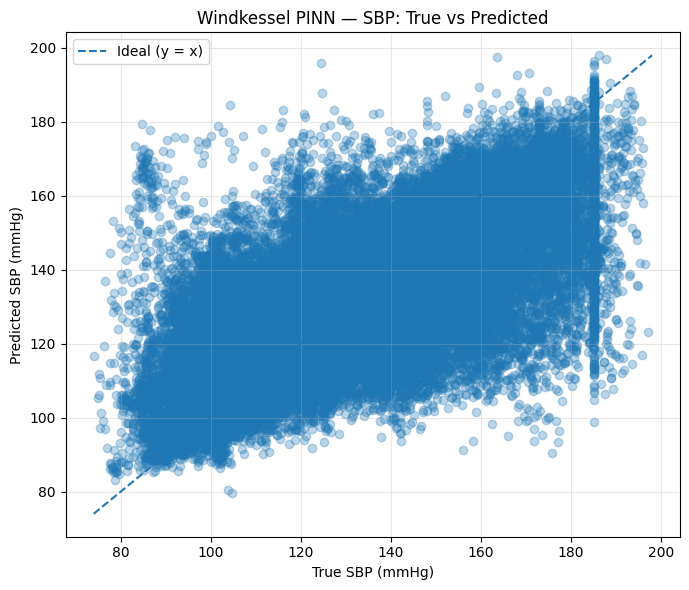

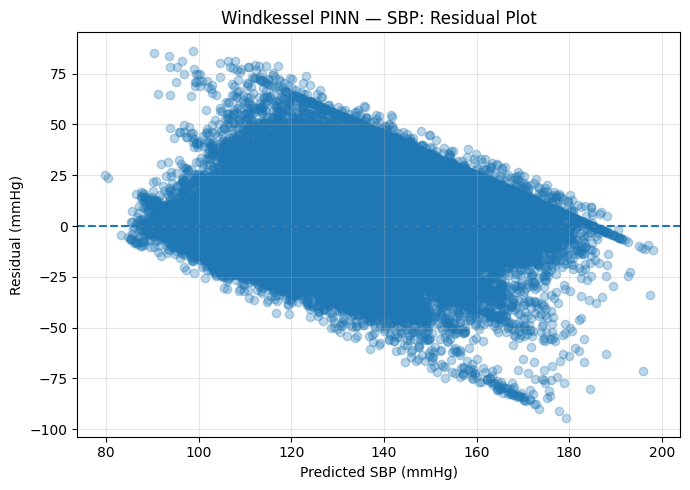

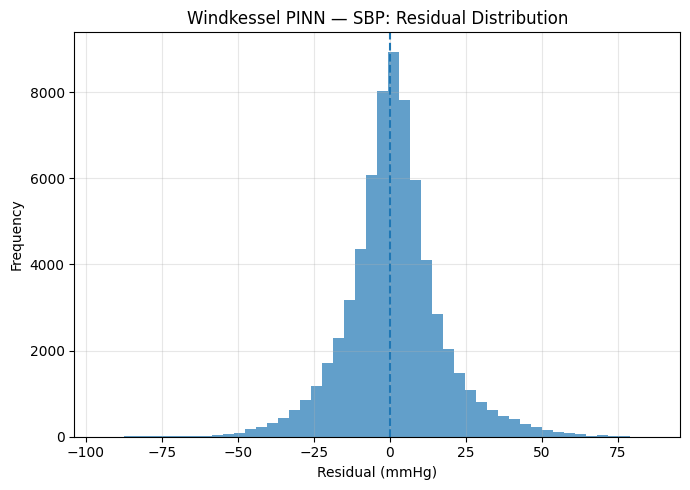

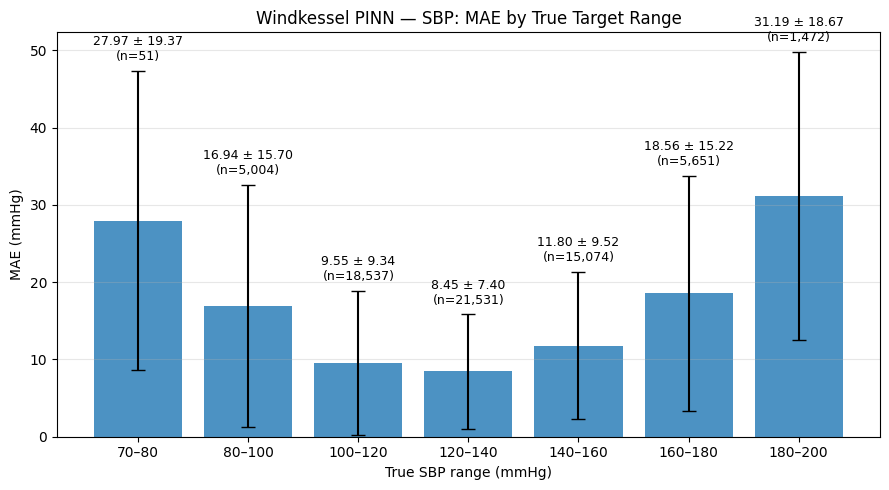


WINDKESSEL PINN — DBP TEST RESULTS
RMSE: 8.6508
MSE : 74.8368
R²  : 0.3966
MAE : 5.9941


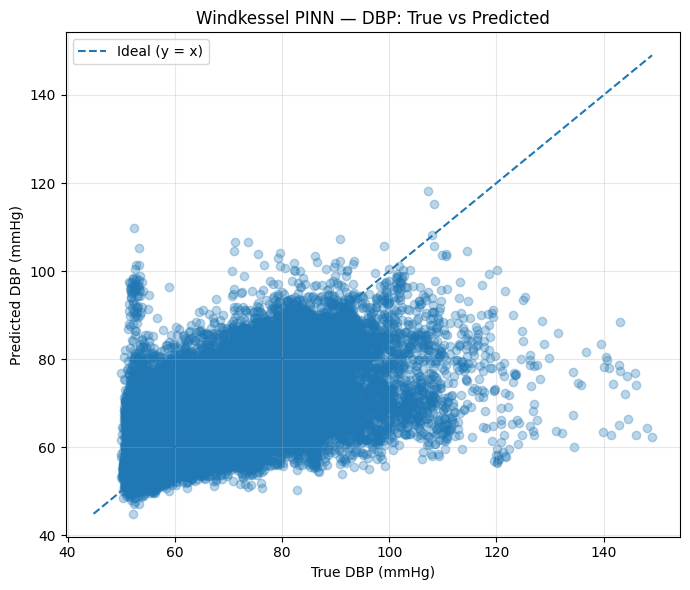

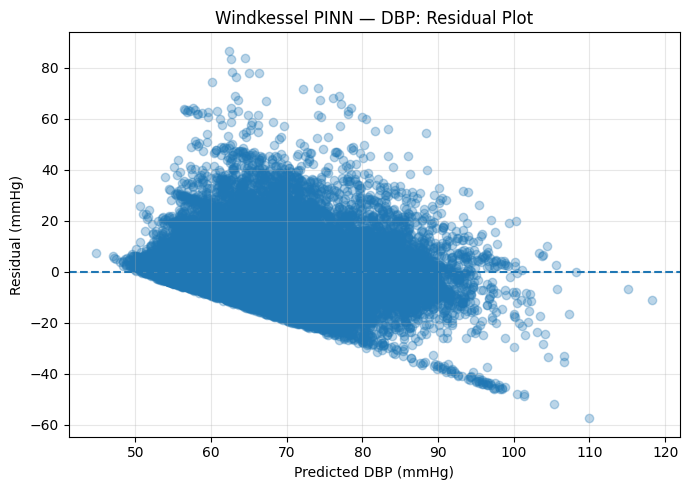

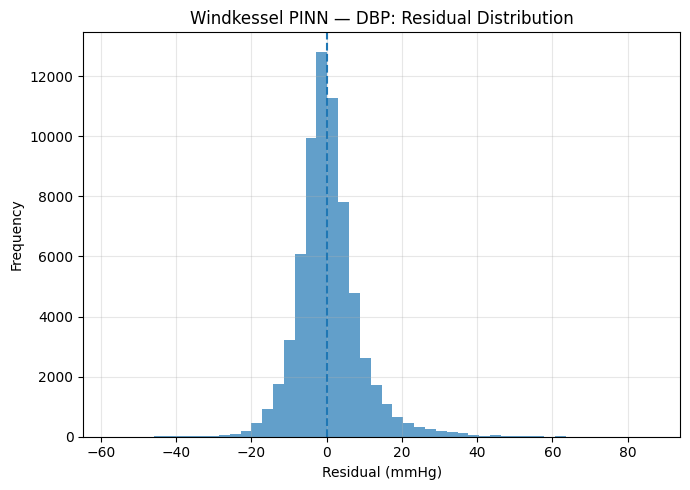

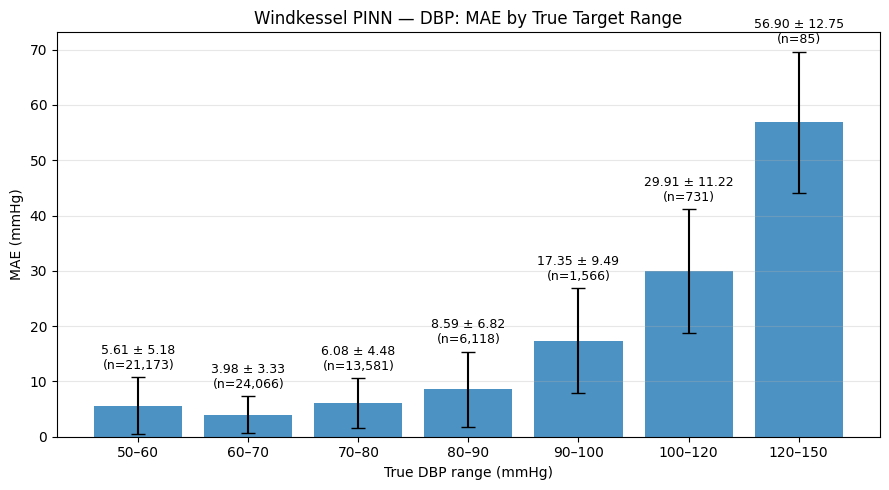

In [30]:
model, results = run_windkessel_pinn(
    X_train, y_train, delay_train,
    X_val, y_val, delay_val,
    X_test, y_test, delay_test,
    RC=RC,
    device=device,
    lambda_phys=0.1
)

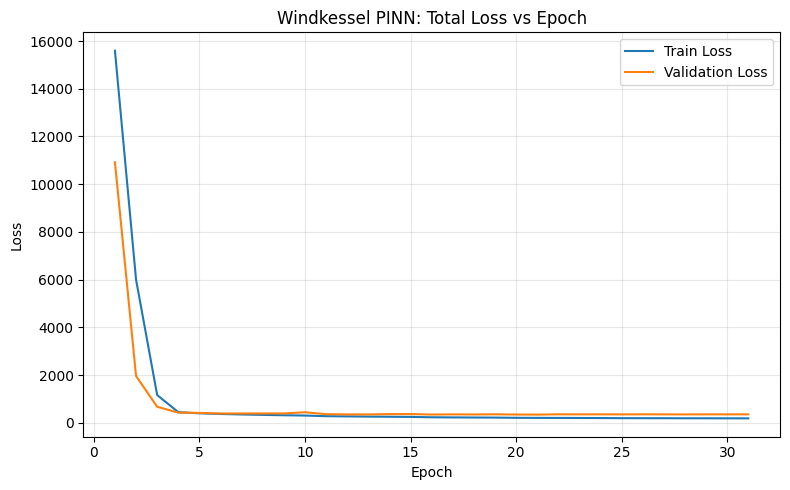

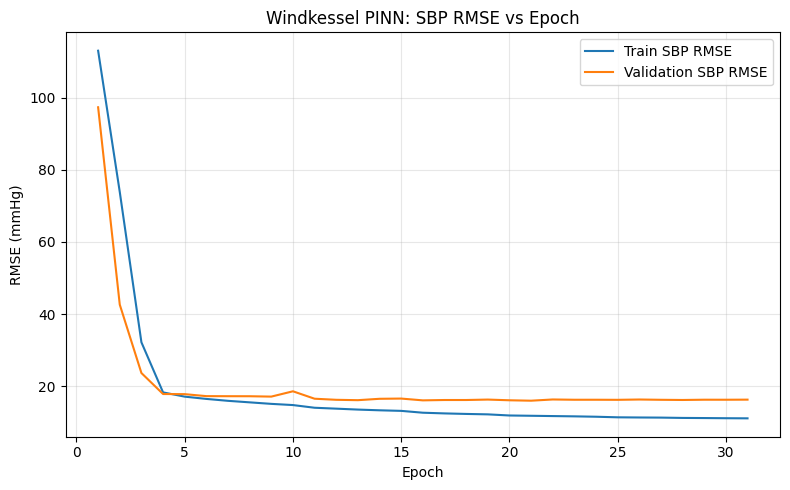

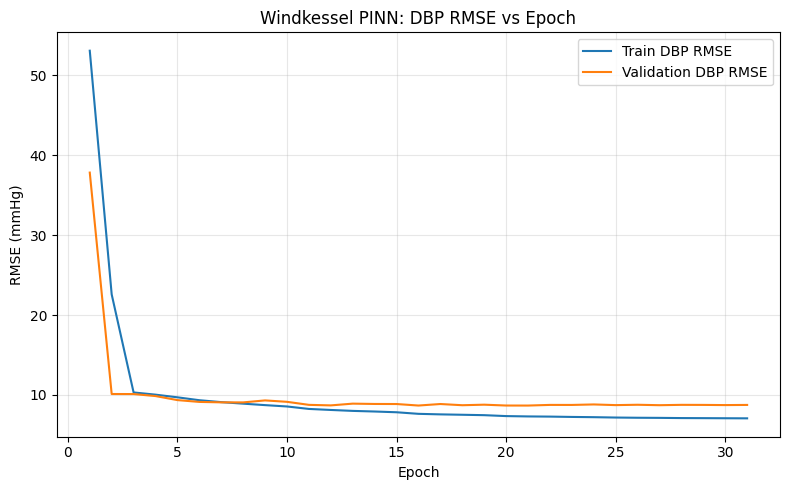

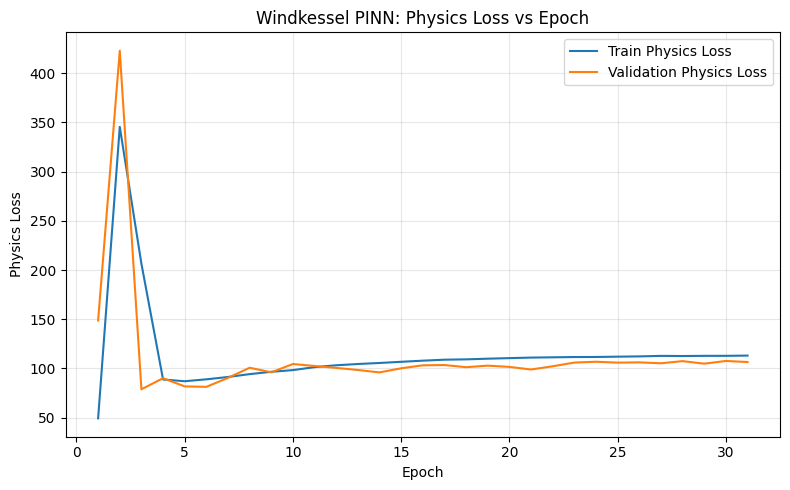

In [31]:
plot_pinn_training_metrics(
    results["history"],
    model_name="Windkessel PINN"
)

Epoch [001/50] | LR: 1.00e-04 | Train Total: 15891.4775 | Train SBP MSE: 12971.2091 | Train DBP MSE: 2878.6632 | Train Phys: 41.6052 | Train RMSE: SBP=113.891, DBP=53.653 | Val Total: 9789.9722 | Val SBP MSE: 8416.5290 | Val DBP MSE: 1225.2395 | Val Phys: 148.2036 | Val RMSE: SBP=91.742, DBP=35.003 | ✓
Epoch [002/50] | LR: 1.00e-04 | Train Total: 6405.3278 | Train SBP MSE: 5523.9220 | Train DBP MSE: 706.3650 | Train Phys: 175.0408 | Train RMSE: SBP=74.323, DBP=26.578 | Val Total: 2815.7114 | Val SBP MSE: 2434.6820 | Val DBP MSE: 243.9632 | Val Phys: 137.0662 | Val RMSE: SBP=49.342, DBP=15.619 | ✓
Epoch [003/50] | LR: 1.00e-04 | Train Total: 1327.1129 | Train SBP MSE: 1073.0879 | Train DBP MSE: 161.0902 | Train Phys: 92.9347 | Train RMSE: SBP=32.758, DBP=12.692 | Val Total: 638.9554 | Val SBP MSE: 474.9049 | Val DBP MSE: 108.0683 | Val Phys: 55.9821 | Val RMSE: SBP=21.792, DBP=10.396 | ✓
Epoch [004/50] | LR: 1.00e-04 | Train Total: 487.8464 | Train SBP MSE: 336.4648 | Train DBP MSE: 106

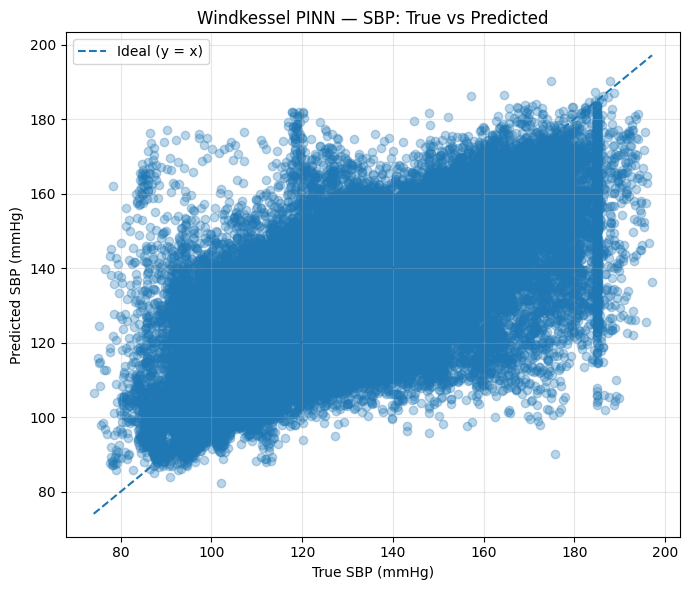

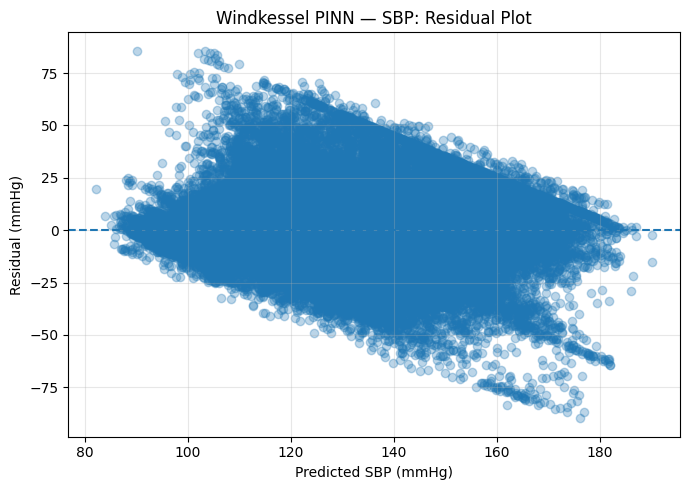

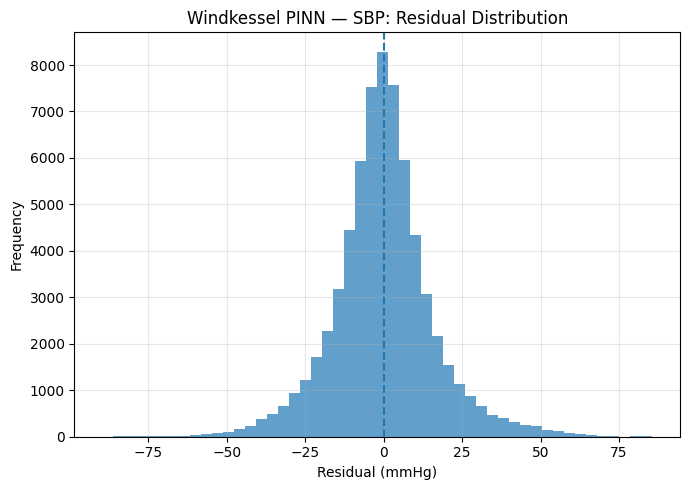

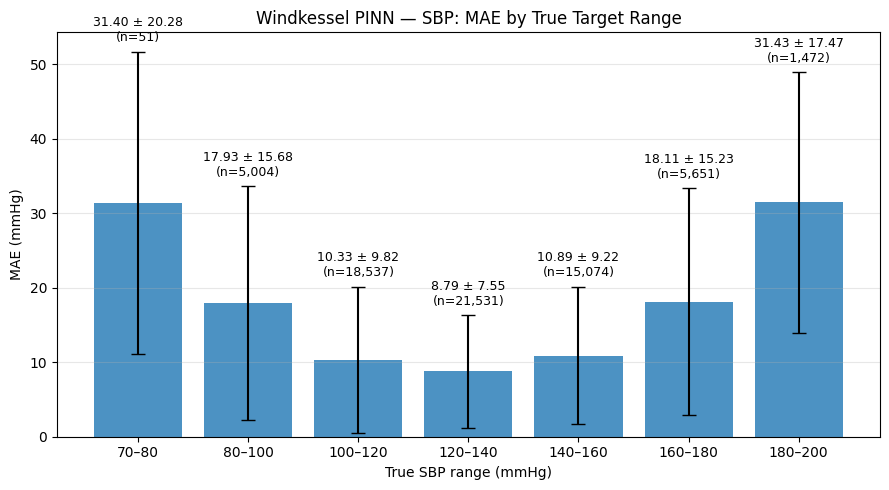


WINDKESSEL PINN — DBP TEST RESULTS
RMSE: 9.8705
MSE : 97.4269
R²  : 0.2144
MAE : 7.3754


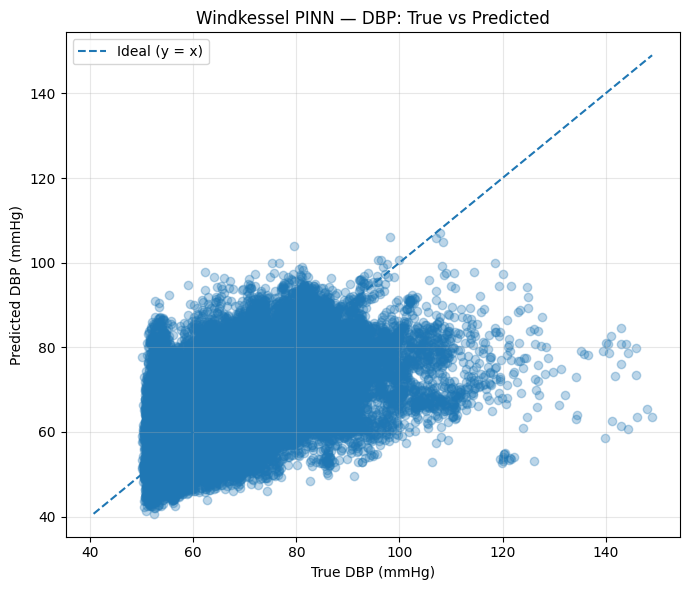

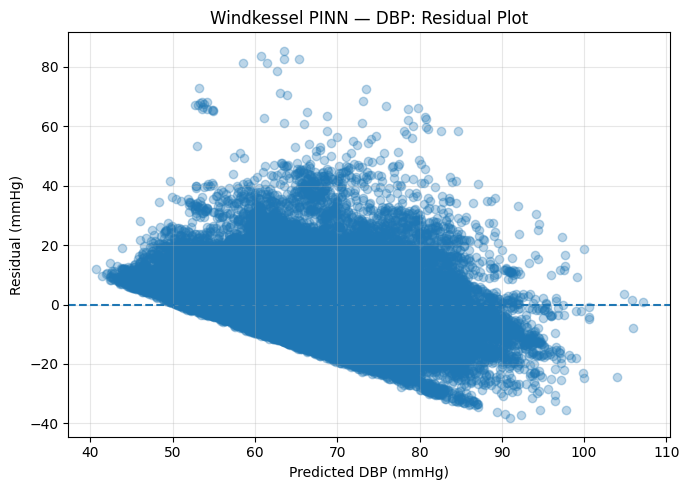

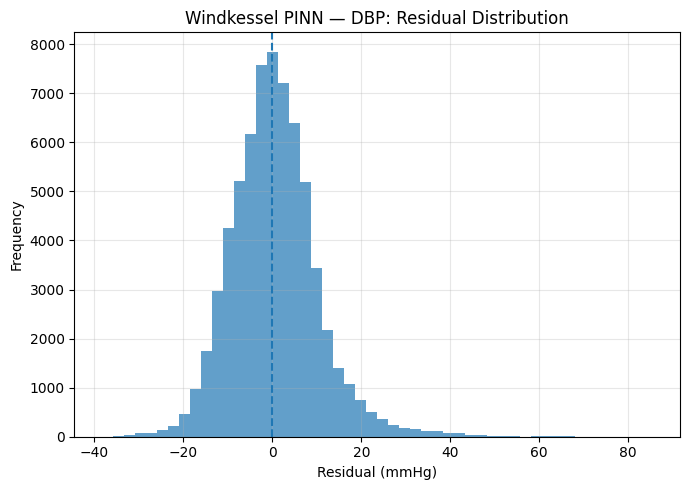

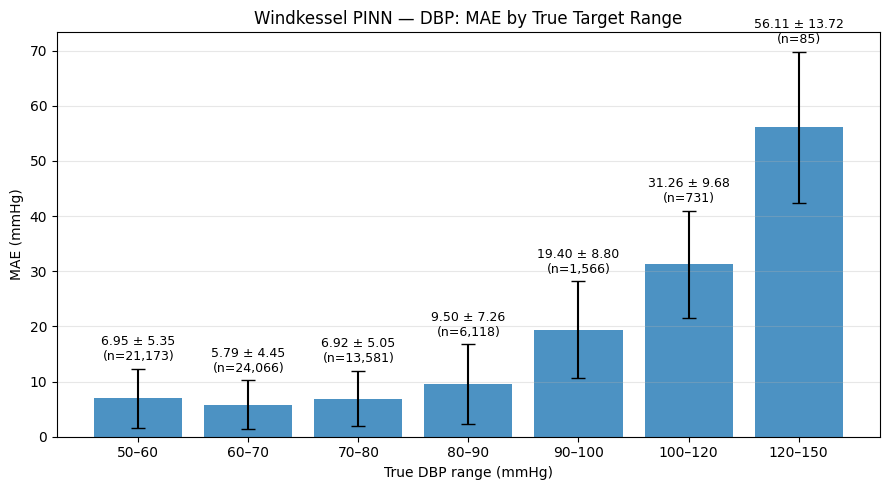

In [32]:
model, results = run_windkessel_pinn(
    X_train, y_train, delay_train,
    X_val, y_val, delay_val,
    X_test, y_test, delay_test,
    RC=RC,
    device=device,
    lambda_phys=1
)

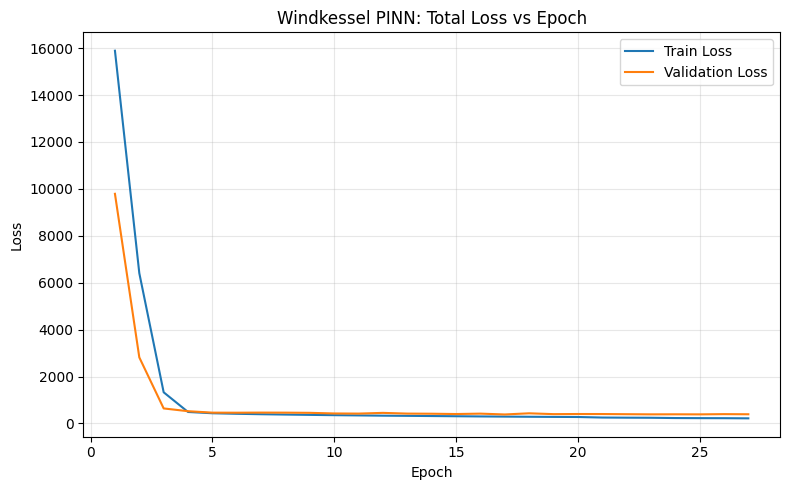

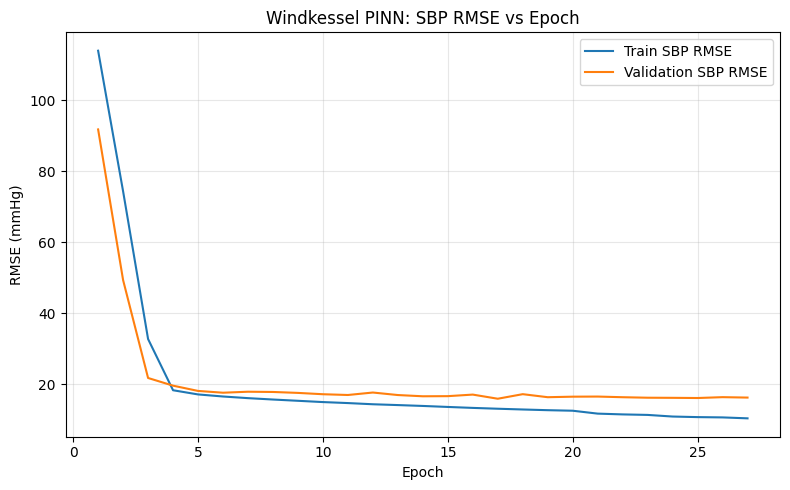

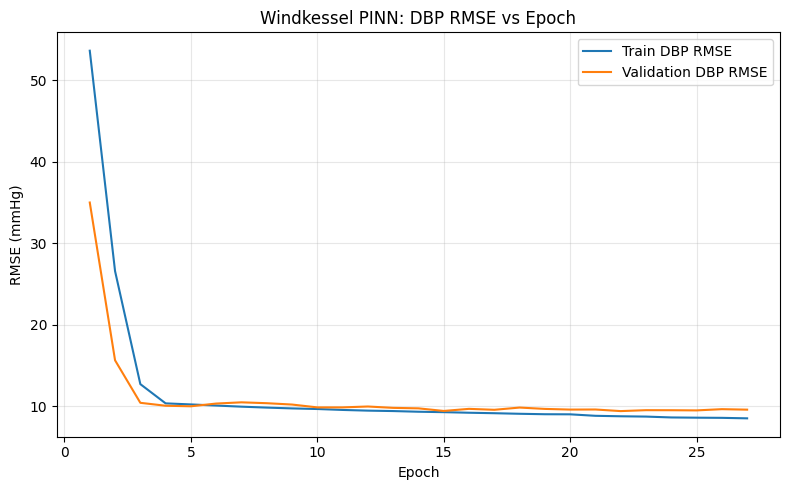

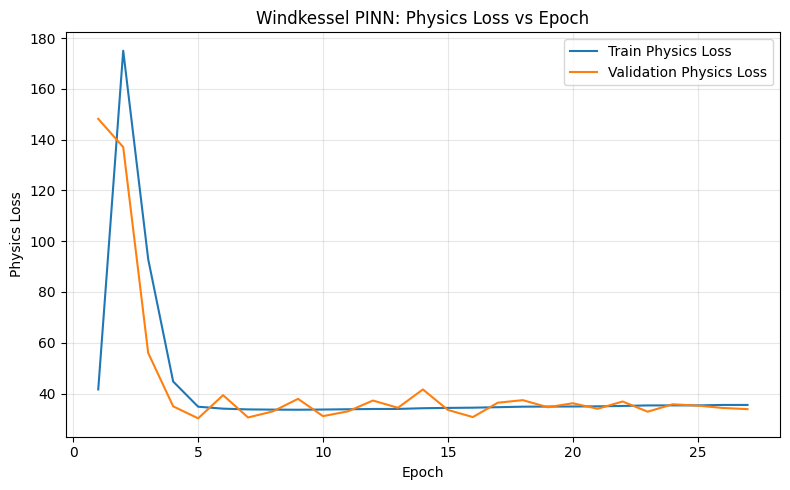

In [33]:
plot_pinn_training_metrics(
    results["history"],
    model_name="Windkessel PINN"
)

Epoch [001/50] | LR: 1.00e-04 | Train Total: 16263.7258 | Train SBP MSE: 13025.8982 | Train DBP MSE: 3135.2501 | Train Phys: 10.2578 | Train RMSE: SBP=114.131, DBP=55.993 | Val Total: 12012.6827 | Val SBP MSE: 9661.2687 | Val DBP MSE: 2188.6240 | Val Phys: 16.2790 | Val RMSE: SBP=98.292, DBP=46.783 | ✓
Epoch [002/50] | LR: 1.00e-04 | Train Total: 7312.9206 | Train SBP MSE: 5814.9083 | Train DBP MSE: 1329.8150 | Train Phys: 16.8197 | Train RMSE: SBP=76.256, DBP=36.467 | Val Total: 3092.2007 | Val SBP MSE: 2379.8539 | Val DBP MSE: 597.7518 | Val Phys: 11.4595 | Val RMSE: SBP=48.784, DBP=24.449 | ✓
Epoch [003/50] | LR: 1.00e-04 | Train Total: 1675.1542 | Train SBP MSE: 1208.2034 | Train DBP MSE: 328.2403 | Train Phys: 13.8710 | Train RMSE: SBP=34.759, DBP=18.117 | Val Total: 925.1594 | Val SBP MSE: 573.3185 | Val DBP MSE: 140.5567 | Val Phys: 21.1284 | Val RMSE: SBP=23.944, DBP=11.856 | ✓
Epoch [004/50] | LR: 1.00e-04 | Train Total: 663.7267 | Train SBP MSE: 386.1361 | Train DBP MSE: 157.

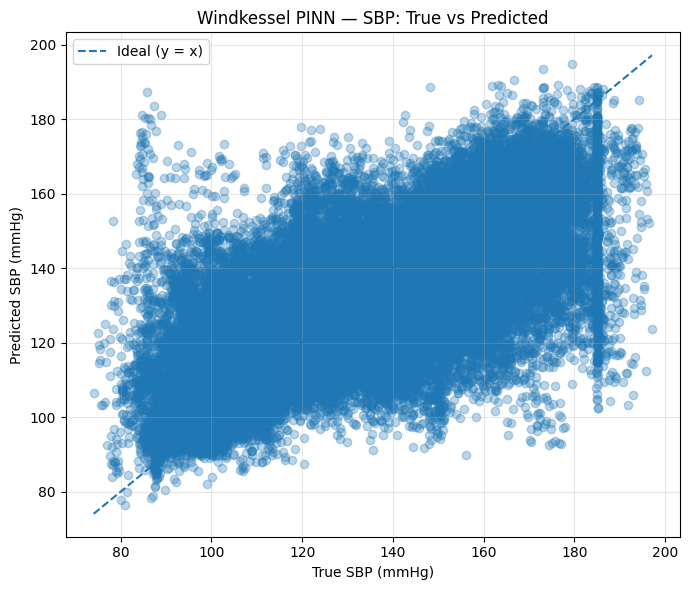

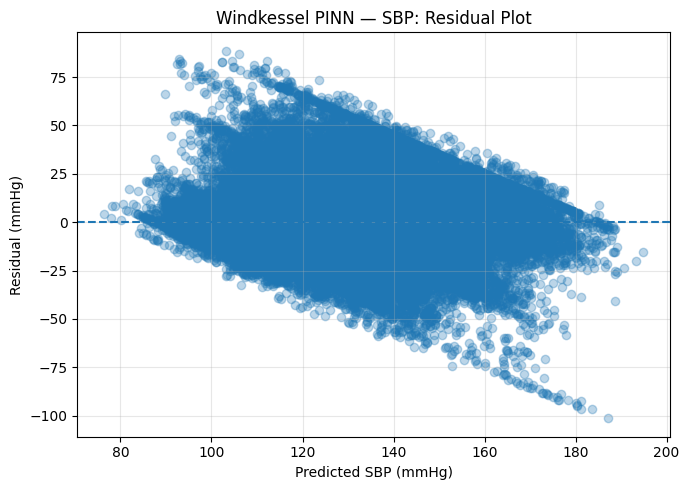

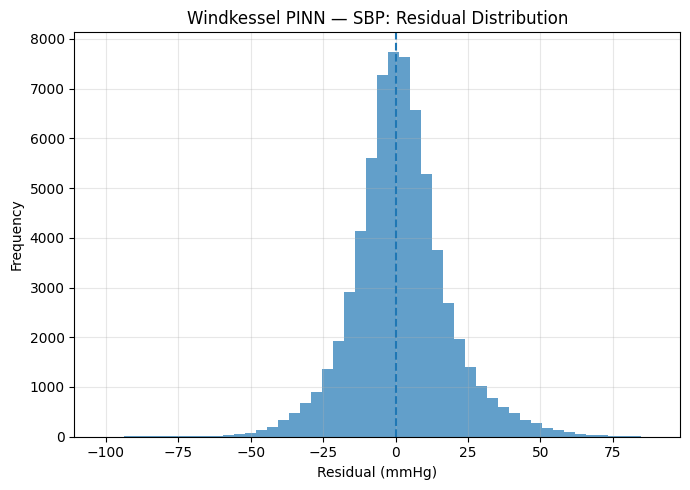

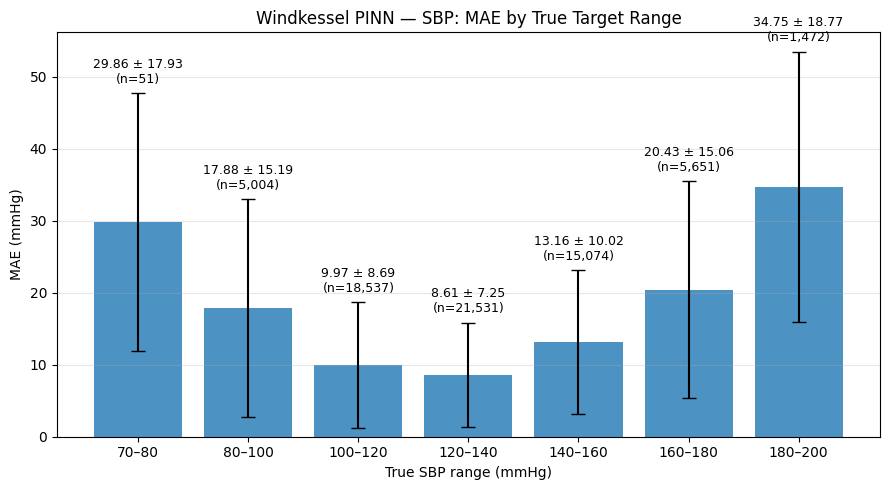


WINDKESSEL PINN — DBP TEST RESULTS
RMSE: 11.4955
MSE : 132.1457
R²  : -0.0655
MAE : 8.8832


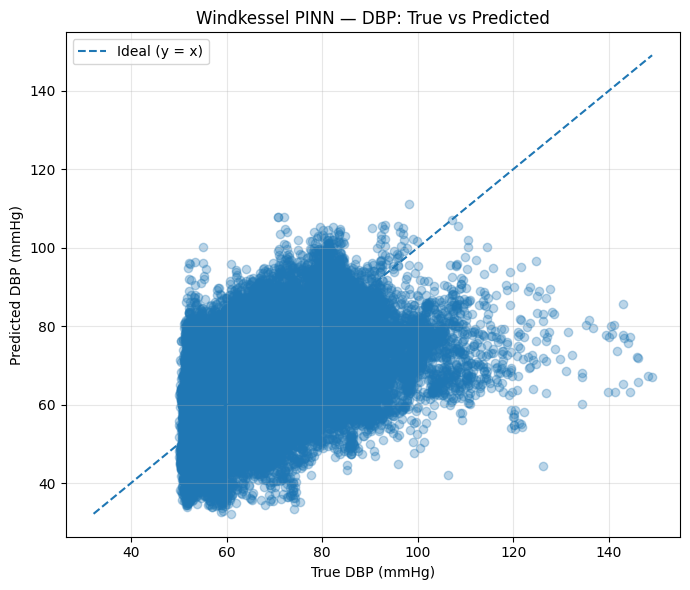

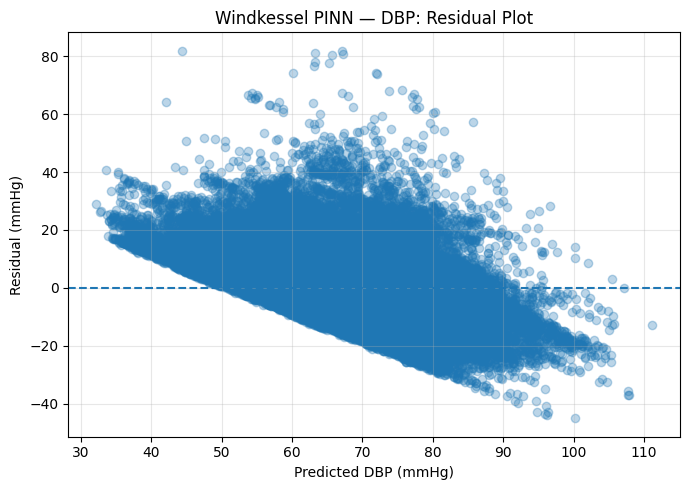

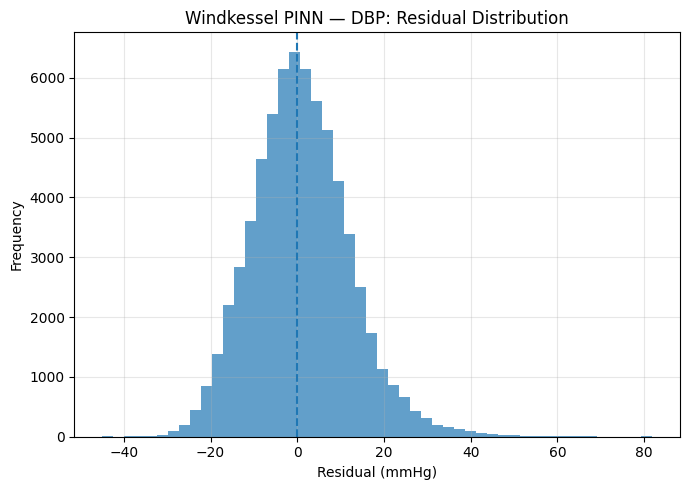

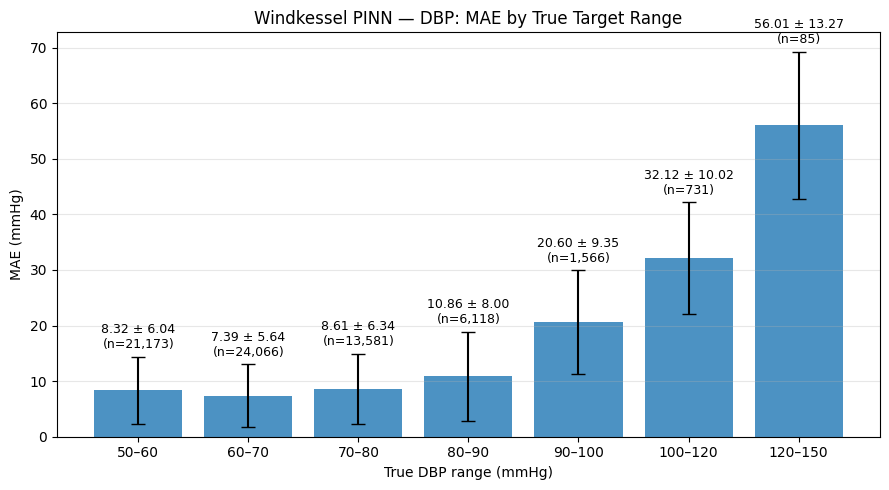

In [34]:
model, results = run_windkessel_pinn(
    X_train, y_train, delay_train,
    X_val, y_val, delay_val,
    X_test, y_test, delay_test,
    RC=RC,
    device=device,
    lambda_phys=10
)

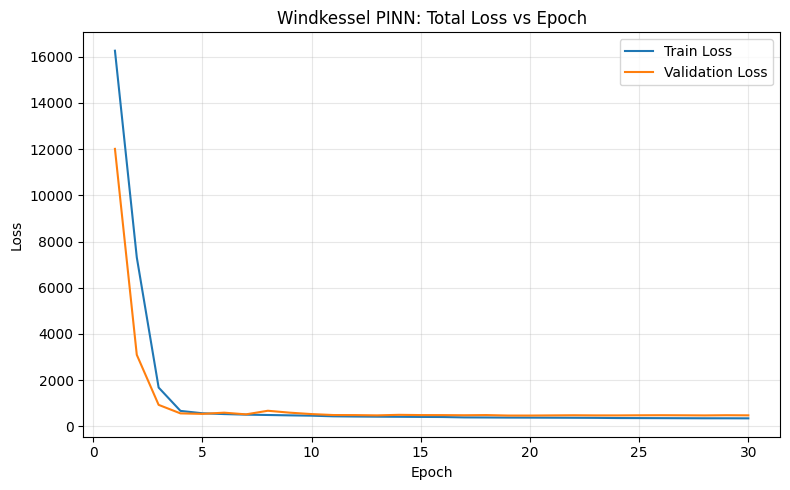

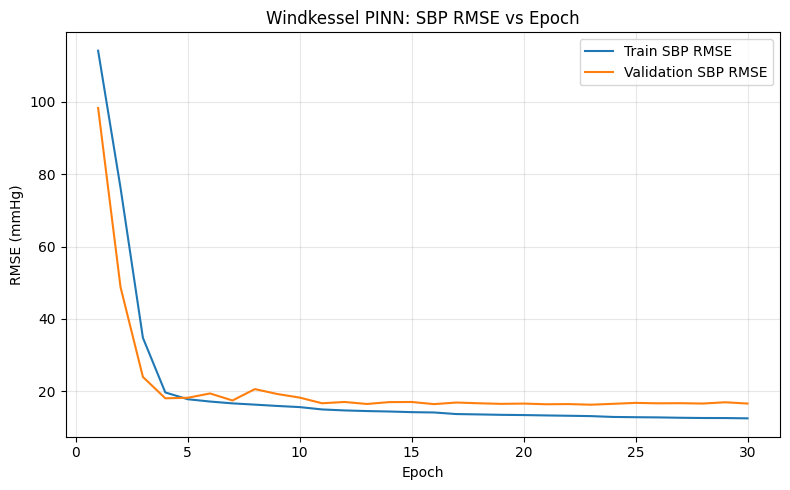

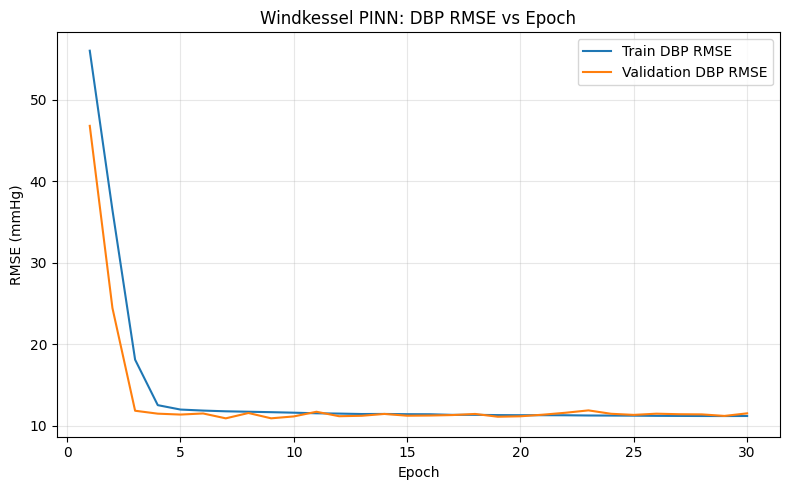

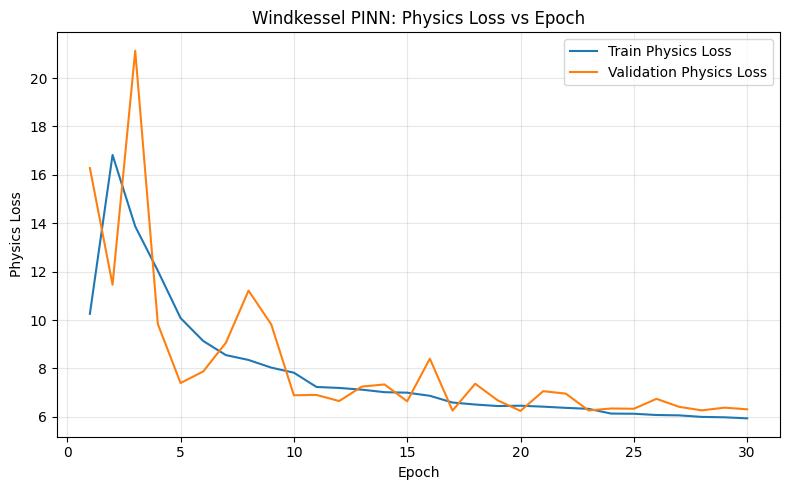

In [35]:
plot_pinn_training_metrics(
    results["history"],
    model_name="Windkessel PINN"
)

Epoch [001/50] | LR: 1.00e-04 | Train Total: 16386.7001 | Train SBP MSE: 12932.3006 | Train DBP MSE: 3356.7542 | Train Phys: 0.9765 | Train RMSE: SBP=113.720, DBP=57.938 | Val Total: 12414.6726 | Val SBP MSE: 9618.3317 | Val DBP MSE: 2582.6079 | Val Phys: 2.1373 | Val RMSE: SBP=98.073, DBP=50.819 | ✓
Epoch [002/50] | LR: 1.00e-04 | Train Total: 7693.1888 | Train SBP MSE: 5904.0318 | Train DBP MSE: 1544.3036 | Train Phys: 2.4485 | Train RMSE: SBP=76.838, DBP=39.298 | Val Total: 4547.8412 | Val SBP MSE: 3413.0981 | Val DBP MSE: 871.3127 | Val Phys: 2.6343 | Val RMSE: SBP=58.422, DBP=29.518 | ✓
Epoch [003/50] | LR: 1.00e-04 | Train Total: 2834.9172 | Train SBP MSE: 1882.5020 | Train DBP MSE: 533.7278 | Train Phys: 4.1869 | Train RMSE: SBP=43.388, DBP=23.103 | Val Total: 1786.3763 | Val SBP MSE: 870.3247 | Val DBP MSE: 235.5769 | Val Phys: 6.8047 | Val RMSE: SBP=29.501, DBP=15.349 | ✓
Epoch [004/50] | LR: 1.00e-04 | Train Total: 1468.9913 | Train SBP MSE: 715.2718 | Train DBP MSE: 246.9804

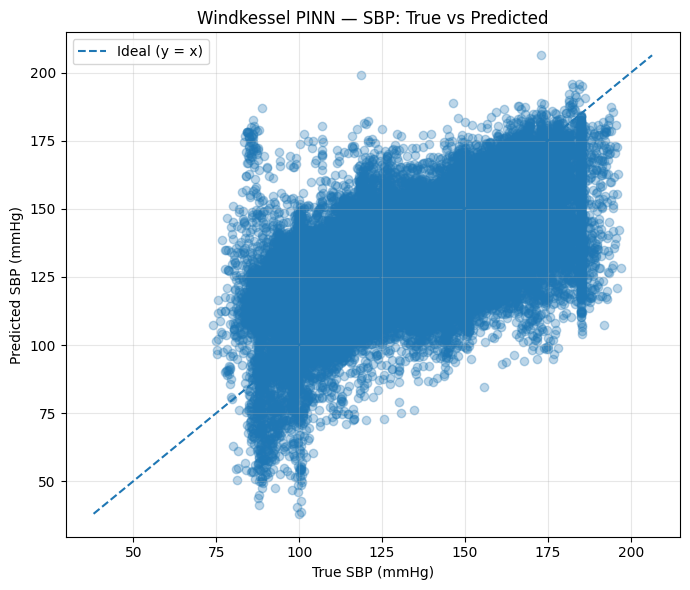

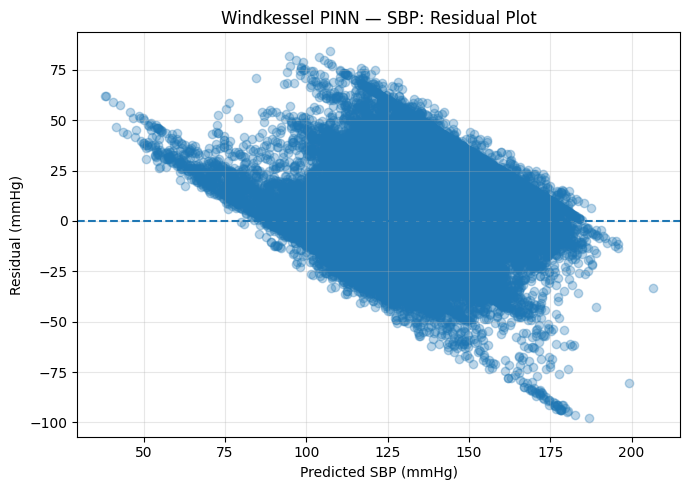

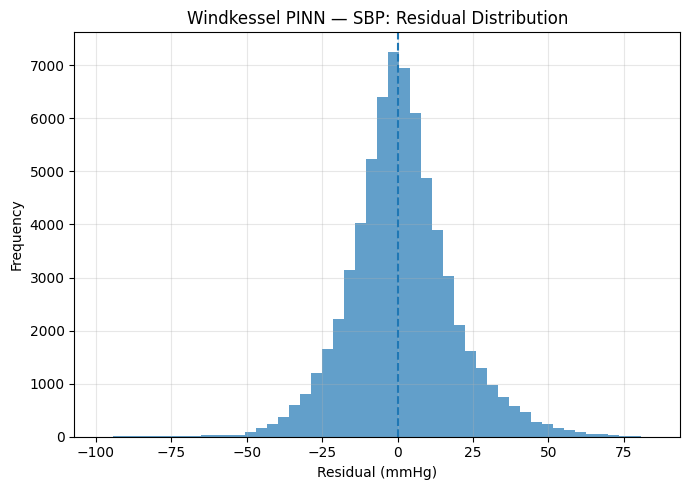

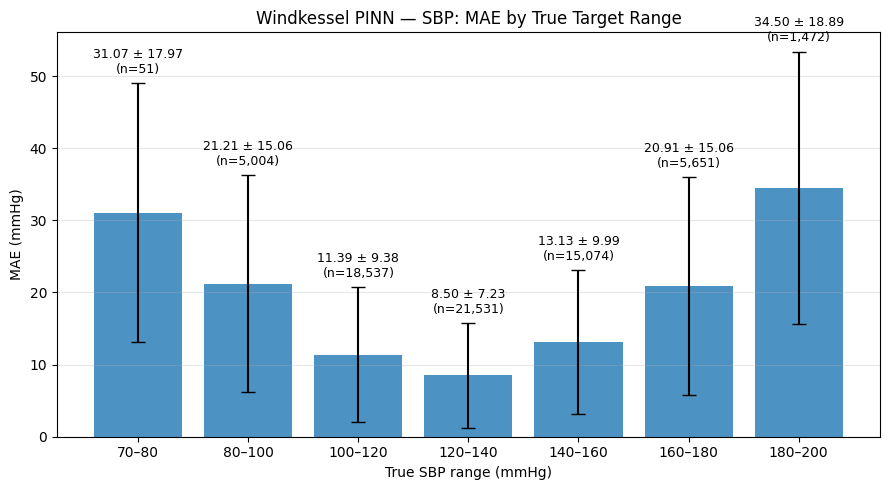


WINDKESSEL PINN — DBP TEST RESULTS
RMSE: 12.6860
MSE : 160.9351
R²  : -0.2977
MAE : 9.8790


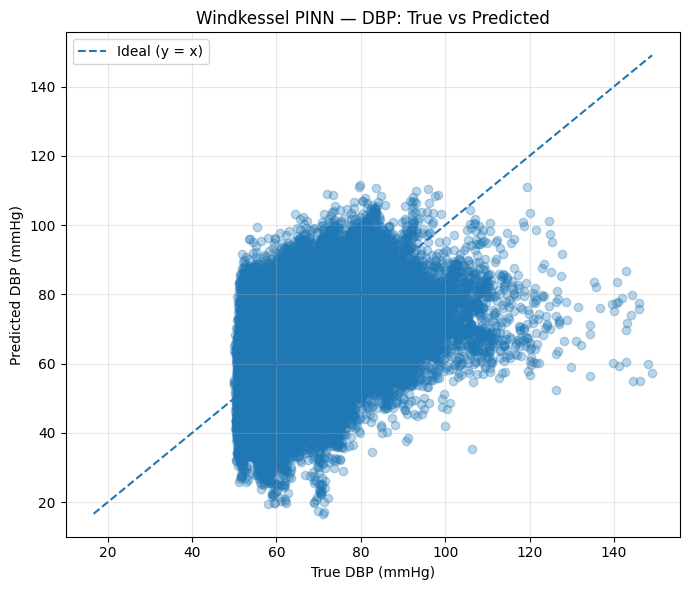

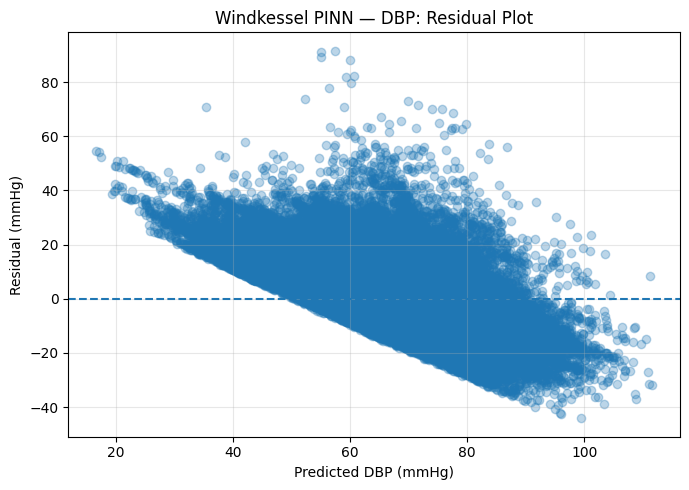

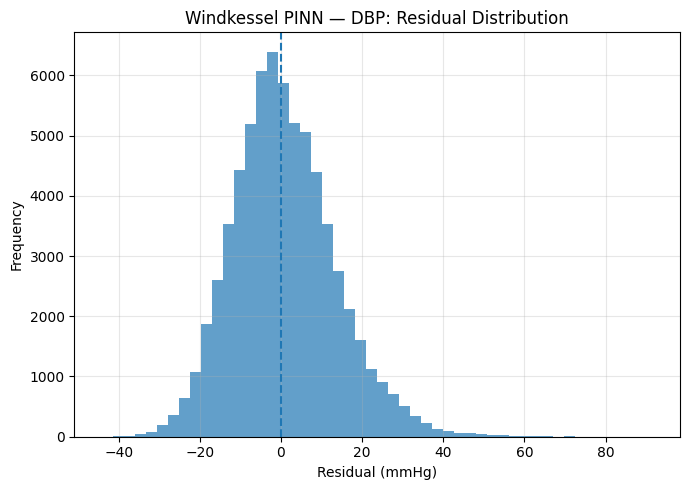

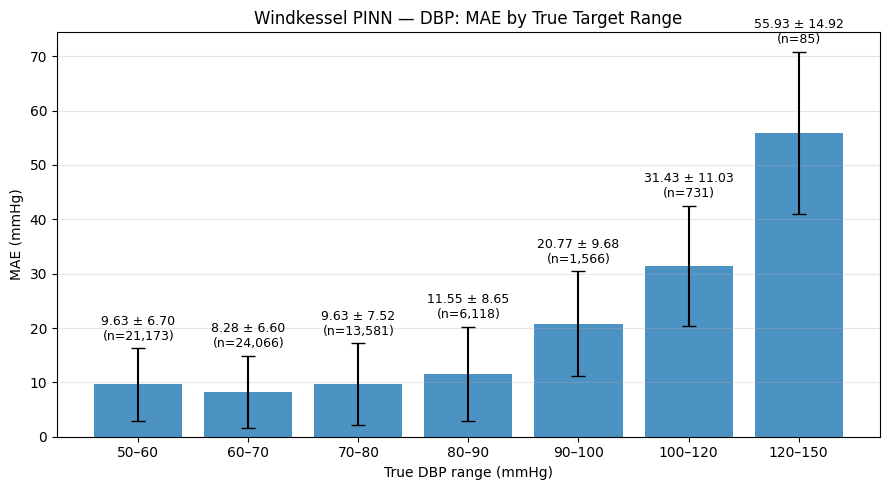

In [36]:
model, results = run_windkessel_pinn(
    X_train, y_train, delay_train,
    X_val, y_val, delay_val,
    X_test, y_test, delay_test,
    RC=RC,
    device=device,
    lambda_phys=100
)

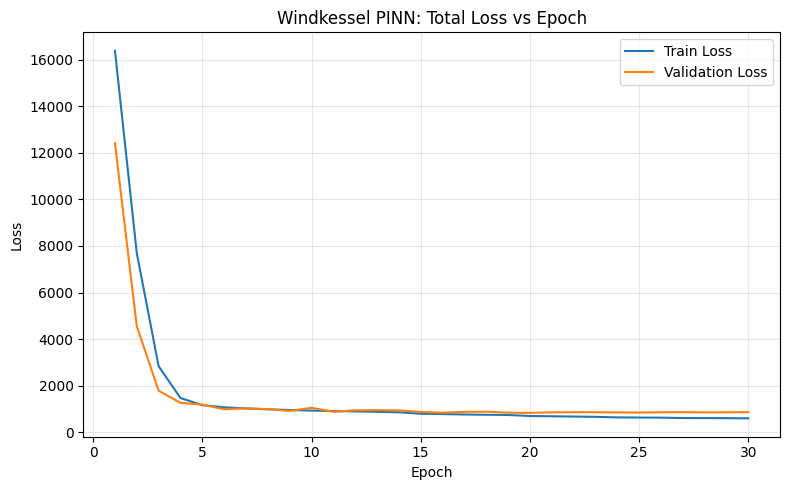

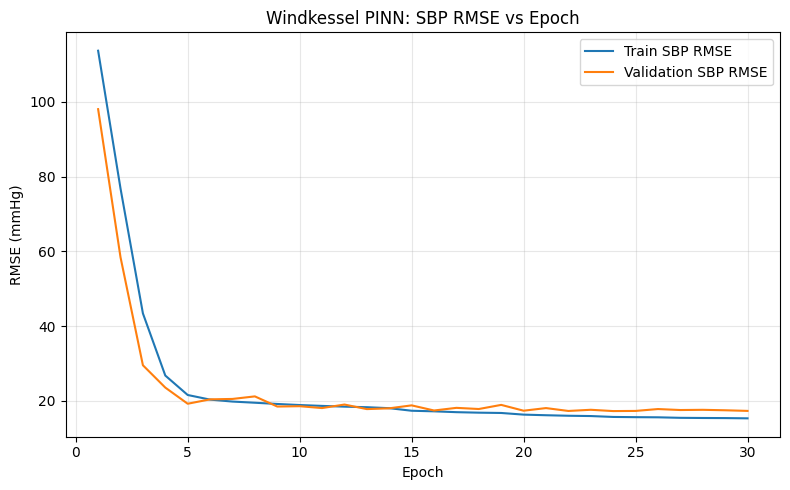

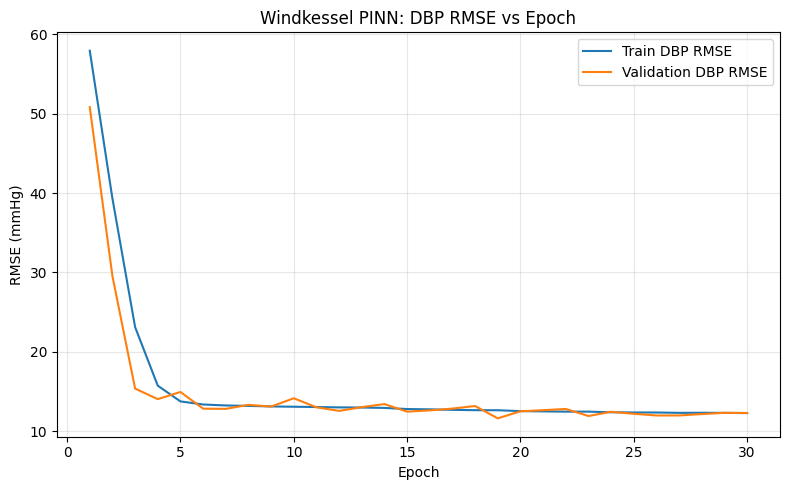

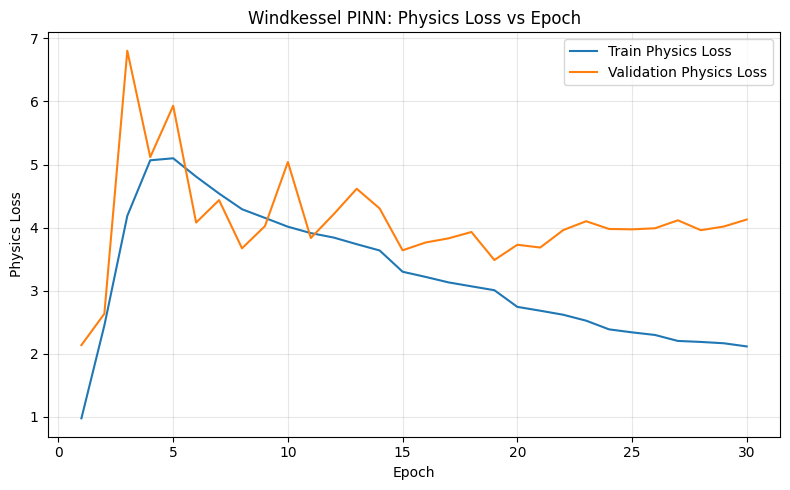

In [37]:
plot_pinn_training_metrics(
    results["history"],
    model_name="Windkessel PINN"
)